# Notebook 4. Reviewer-Response Experiments for the Manuscript Proposed Model

This notebook executes the Round-1 technical experiments for the **same proposed model described in the manuscript**: a frozen ARX linear skip branch plus causal temporal convolution, a three-layer GRU, causal self-attention, additive attention pooling, residual gating, a nonlinear residual head, and auxiliary total-yield supervision.

The architecture is not replaced by a compact tree model. The fixed manuscript configuration is used throughout: 30 × 41 causal input, 5-minute primary horizon, hidden size 64, three GRU layers, two attention heads, dropout 0.08, and the published auxiliary/consistency/bounds weights. Component removals occur only in explicitly labelled ablation experiments.

**Evidence boundary.** The historical test split was exposed in earlier project workflows. Historical-test metrics and significance tests below are therefore post-selection/descriptive. Rolling-origin assessment uses development data only, and leave-one-scenario-out (LOSO) is reported as a scenario-generalization stress test. A new external or prospectively frozen trajectory set remains necessary for a fully confirmatory superiority claim.


In [1]:
import gc
import hashlib
import json
import math
import os
import platform
import random
import time
import warnings
from pathlib import Path
from textwrap import fill

CPU_THREADS = max(1, min(8, (os.cpu_count() or 4) - 2))
for variable in [
    'OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS', 'BLIS_NUM_THREADS',
]:
    os.environ[variable] = str(CPU_THREADS)
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy.stats import norm, t as student_t, wilcoxon
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from torch import nn

warnings.filterwarnings('default')
torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(max(1, min(2, CPU_THREADS)))
except RuntimeError:
    pass
torch.set_float32_matmul_precision('high')

SEED = 42
CSV_PATH = Path('FCCU_DYNAMIC_NN_DATASET.csv')
MAIN_LOOKBACK = 30
MAIN_HORIZON = 5
PRIMARY_TARGETS = [
    'gasoline_proxy_wt_pct_of_feed',
    'light_cycle_oil_wt_pct_of_feed',
    'lpg_wt_pct_of_feed',
    'slurry_wt_pct_of_feed',
]
AUX_TARGET = 'measured_products_wt_pct_of_feed'
PROPOSED_FINAL_MODEL = 'Proposed Hybrid ARX–Residual Deep Sequence Model'
REVIEWER_SEEDS = [11, 23, 42, 71, 101, 131, 173, 211, 257, 307]
ABLATION_SEEDS = [11, 42, 101]
COMPARATOR_SEEDS = [42]
REVIEWER_HORIZONS = [1, 5, 15, 30]

MANUSCRIPT_MODEL_CONFIG = {
    'hidden_dim': 64,
    'recurrent_layers': 3,
    'dropout': 0.08,
    'num_heads': 2,
}
MANUSCRIPT_TRAINING_CONFIG = {
    'learning_rate': 0.002040,
    'weight_decay': 0.000040,
    'batch_size': 128,
    'validation_batch_size': 256,
    'max_epochs': 36,
    'patience': 6,
    'grad_clip': 1.0,
    'aux_weight': 0.142631,
    'consistency_weight': 0.066263,
    'bounds_weight': 0.044448,
}
ARX_ALPHA = 1.0
ARX_SOLVER_TOLERANCE = 1e-8
ARX_SOLVER_MAX_ITERATIONS = 10000

if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

def set_global_seed(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

def clear_accelerator_cache():
    gc.collect()
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

def sync_accelerator():
    if DEVICE.type == 'mps':
        torch.mps.synchronize()
    elif DEVICE.type == 'cuda':
        torch.cuda.synchronize()

mpl.rcParams.update({
    'font.family': 'Times New Roman', 'font.size': 18,
    'axes.titlesize': 20, 'axes.labelsize': 18,
    'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'legend.fontsize': 18, 'figure.dpi': 350, 'savefig.dpi': 350,
    'axes.spines.top': False, 'axes.spines.right': False,
})
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 240)

TARGET_LABELS = {
    'gasoline_proxy_wt_pct_of_feed': 'gasoline proxy',
    'light_cycle_oil_wt_pct_of_feed': 'LCO',
    'lpg_wt_pct_of_feed': 'LPG',
    'slurry_wt_pct_of_feed': 'slurry',
    'macro': 'macro',
}

def display_complete_table(frame, *, split_by=None, rows_per_part=18, part_label='Table', sort_by=None):
    table = frame.copy()
    if sort_by is not None:
        table = table.sort_values(sort_by)
    def show_parts(part, heading):
        part = part.reset_index(drop=True)
        total_parts = max(1, math.ceil(len(part) / rows_per_part))
        for part_index, start in enumerate(range(0, max(len(part), 1), rows_per_part), start=1):
            stop = min(start + rows_per_part, len(part))
            suffix = f' — part {part_index}/{total_parts}' if total_parts > 1 else ''
            display(Markdown(f'#### {heading}{suffix} ({stop - start} rows)'))
            display(part.iloc[start:stop].reset_index(drop=True))
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.expand_frame_repr', False):
        if split_by is None:
            show_parts(table, part_label)
        else:
            split_columns = [split_by] if isinstance(split_by, str) else list(split_by)
            group_key = split_columns[0] if len(split_columns) == 1 else split_columns
            for key, part in table.groupby(group_key, sort=False, dropna=False):
                key_values = key if isinstance(key, tuple) else (key,)
                key_text = ', '.join(f'{column}={value}' for column, value in zip(split_columns, key_values))
                show_parts(part, f'{part_label}: {key_text}')

hardware_df = pd.DataFrame([{
    'selected_backend': str(DEVICE),
    'mps_available': bool(hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()),
    'torch_version': torch.__version__,
    'machine': platform.machine(),
    'cpu_threads_for_numeric_work': CPU_THREADS,
    'float_policy': 'float32',
    'seed_count_full_model': len(REVIEWER_SEEDS),
}])
display(hardware_df)


,selected_backend,mps_available,torch_version,machine,cpu_threads_for_numeric_work,float_policy,seed_count_full_model
0,mps,True,2.10.0,arm64,8,float32,10


## A. Data, predictors, leakage controls, and causal windows

The source is a simulated FCCU benchmark containing seven scenarios. The final input contains 37 exogenous process variables and four lagged target channels. Scenario identifiers, timestamps, split labels, condition/fault labels, and fault-timing fields are used only for ordering, grouping, and audit; none enters the predictive tensor. Imputation and standardization are fitted on the training subset only, and windows never cross scenario or split boundaries.


In [2]:

df = pd.read_csv(CSV_PATH)

feature_cols = [
    'feed_flow_tph',
    'ambient_temperature_Tatm_degF',
    'feed_temperature_T1_degF',
    'reactor_inlet_feed_temperature_T2_degF',
    'reactor_riser_temperature_Tr_degC',
    'regenerator_temperature_Treg_degF',
    'reactor_pressure_P4_psia',
    'regenerator_minus_reactor_pressure_deltaP_psig',
    'regenerator_pressure_P6_psia',
    'regenerator_total_air_flow_Fair_mol_s',
    'furnace_firebox_temperature_T3_degF',
    'standpipe_catalyst_level_Lsp_ft',
    'stack_gas_temperature_Tcyc_degF',
    'stack_gas_minus_regenerator_temperature_Tcyc_Treg_degF',
    'stack_gas_co_Cco_g_ppm',
    'stack_gas_o2_Co2_g_mol_pct',
    'fractionator_overhead_pressure_P5_psia',
    'regenerated_catalyst_flow_Frgc_lb_min',
    'spent_catalyst_flow_Fsc_lb_min',
    'combustion_air_blower_current_ACAB_amp',
    'wet_gas_compressor_current_AWGC_amp',
    'furnace_fuel_flow_F5_scf_min',
    'combustion_air_flow_F7_lb_min',
    'stack_gas_flow_Fsg_mol_min',
    'cab_suction_pressure_P1_psia',
    'cab_discharge_pressure_P2_psia',
    'fractionator_overhead_temperature_Tfra_degF',
    'fractionator_mid_temperature_T10_degF',
    'fractionator_bottom_temperature_T20_degF',
    'valve_fractionator_pressure_V4_pct',
    'valve_regenerator_temperature_V6_pct',
    'valve_regenerator_pressure_V7_pct',
    'valve_reactor_inventory_V3_pct',
    'valve_preheated_feed_temperature_V1_pct',
    'valve_reactor_temperature_V2_pct',
    'valve_accumulator_level_V9_pct',
    'valve_fractionator_temperature_V8_pct',
]

print(f'Dataset shape: {df.shape}')
print(f'Process feature count: {len(feature_cols)}')
print(f'Target count: {len(PRIMARY_TARGETS)}')
print(f'Lookback: {MAIN_LOOKBACK}; horizon: {MAIN_HORIZON}')
print('Split sizes:')
display(df['dataset_split'].value_counts().reindex(['train', 'validation', 'test']).to_frame('rows'))


def rmse_vector(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))


def mae_vector(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred), axis=0)


def smape(y_true, y_pred, eps=1e-8):
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps), axis=0)


def evaluate_predictions(y_true, y_pred, target_names, model_name, split_name):
    rows = []
    rmse_vals = rmse_vector(y_true, y_pred)
    mae_vals = mae_vector(y_true, y_pred)
    smape_vals = smape(y_true, y_pred)
    for idx, target in enumerate(target_names):
        rows.append({
            'model': model_name,
            'split': split_name,
            'target': target,
            'rmse': float(rmse_vals[idx]),
            'mae': float(mae_vals[idx]),
            'r2': float(r2_score(y_true[:, idx], y_pred[:, idx])),
            'smape': float(smape_vals[idx]),
        })
    rows.append({
        'model': model_name,
        'split': split_name,
        'target': 'macro',
        'rmse': float(np.mean(rmse_vals)),
        'mae': float(np.mean(mae_vals)),
        'r2': float(np.mean([r2_score(y_true[:, idx], y_pred[:, idx]) for idx in range(y_true.shape[1])])),
        'smape': float(np.mean(smape_vals)),
    })
    return pd.DataFrame(rows)


def prepare_sequence_experiment(df_source, feature_cols, target_cols, aux_target_col=None, lookback=30, horizon=5, include_target_history=False):
    work = df_source.sort_values(['scenario_id', 'time_min']).reset_index(drop=True).copy()
    feature_imputer = SimpleImputer(strategy='median')
    feature_imputer.fit(work.loc[work['dataset_split'] == 'train', feature_cols])
    work.loc[:, feature_cols] = feature_imputer.transform(work[feature_cols])
    split_bundle = {key: {'X': [], 'y': [], 'y_aux': [], 'y_hist': [], 'meta': []} for key in ['train', 'validation', 'test']}
    meta_cols = ['scenario_id', 'condition', 'dataset_split', 'time_min', 'fault_type', 'fault_start_min', 'fault_transition_end_min', 'is_faulty_scenario']
    for (_, split_name), group in work.groupby(['scenario_id', 'dataset_split'], sort=False):
        group = group.sort_values('time_min').reset_index(drop=True)
        x_exog = group[feature_cols].to_numpy(dtype=np.float32)
        y = group[target_cols].to_numpy(dtype=np.float32)
        y_aux = group[[aux_target_col]].to_numpy(dtype=np.float32) if aux_target_col is not None else None
        x_full = np.concatenate([x_exog, y], axis=1) if include_target_history else x_exog
        for end_idx in range(lookback - 1, len(group) - horizon):
            start_idx = end_idx - lookback + 1
            target_idx = end_idx + horizon
            split_bundle[split_name]['X'].append(x_full[start_idx:end_idx + 1])
            split_bundle[split_name]['y'].append(y[target_idx])
            split_bundle[split_name]['y_hist'].append(y[start_idx:end_idx + 1])
            if y_aux is not None:
                split_bundle[split_name]['y_aux'].append(y_aux[target_idx])
            meta_record = group.loc[target_idx, meta_cols].to_dict()
            meta_record['window_end_time_min'] = float(group.loc[end_idx, 'time_min'])
            meta_record['lookback'] = lookback
            meta_record['horizon'] = horizon
            split_bundle[split_name]['meta'].append(meta_record)
    for split_name, payload in split_bundle.items():
        payload['X'] = np.stack(payload['X']).astype(np.float32)
        payload['y'] = np.stack(payload['y']).astype(np.float32)
        payload['y_hist'] = np.stack(payload['y_hist']).astype(np.float32)
        payload['meta'] = pd.DataFrame(payload['meta'])
        payload['y_aux'] = np.stack(payload['y_aux']).astype(np.float32) if aux_target_col is not None else None
    x_scaler = StandardScaler().fit(split_bundle['train']['X'].reshape(-1, split_bundle['train']['X'].shape[-1]))
    y_scaler = StandardScaler().fit(split_bundle['train']['y'])
    aux_scaler = StandardScaler().fit(split_bundle['train']['y_aux']) if aux_target_col is not None else None
    for split_name, payload in split_bundle.items():
        original_shape = payload['X'].shape
        payload['X_scaled'] = x_scaler.transform(payload['X'].reshape(-1, original_shape[-1])).reshape(original_shape).astype(np.float32)
        payload['y_scaled'] = y_scaler.transform(payload['y']).astype(np.float32)
        payload['y_aux_scaled'] = aux_scaler.transform(payload['y_aux']).astype(np.float32) if aux_scaler is not None else None
    input_feature_names = list(feature_cols) + (list(target_cols) if include_target_history else [])
    return {
        'splits': split_bundle,
        'imputer': feature_imputer,
        'x_scaler': x_scaler,
        'y_scaler': y_scaler,
        'aux_scaler': aux_scaler,
        'feature_cols': list(feature_cols),
        'input_feature_names': input_feature_names,
        'target_cols': list(target_cols),
        'lookback': lookback,
        'horizon': horizon,
        'include_target_history': include_target_history,
    }


def flatten_scaled_windows(bundle):
    return {split: payload['X_scaled'].reshape(payload['X_scaled'].shape[0], -1) for split, payload in bundle['splits'].items()}


def measure_inference_time(function, repeats=7):
    function()
    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        function()
        timings.append((time.perf_counter() - start) * 1000.0)
    return float(np.median(timings))

bundle_exog = prepare_sequence_experiment(df, feature_cols, PRIMARY_TARGETS, AUX_TARGET, MAIN_LOOKBACK, MAIN_HORIZON, include_target_history=False)
bundle_arx = prepare_sequence_experiment(df, feature_cols, PRIMARY_TARGETS, AUX_TARGET, MAIN_LOOKBACK, MAIN_HORIZON, include_target_history=True)
flat_exog = flatten_scaled_windows(bundle_exog)
flat_arx = flatten_scaled_windows(bundle_arx)

window_summary_df = pd.DataFrame([
    {'split': split, 'windows': bundle_arx['splits'][split]['X'].shape[0], 'tensor_shape': str(tuple(bundle_arx['splits'][split]['X'].shape))}
    for split in ['train', 'validation', 'test']
])
display(window_summary_df)

assert len(feature_cols) == 37
assert bundle_arx['splits']['train']['X_scaled'].shape[-1] == 41
assert not set(PRIMARY_TARGETS).intersection(feature_cols)
assert np.allclose(df[AUX_TARGET].to_numpy(), df[PRIMARY_TARGETS].sum(axis=1).to_numpy(), atol=1e-6)

excluded_predictor_df = pd.DataFrame({
    'excluded_group': ['identifiers', 'time variables', 'split metadata', 'condition/fault labels', 'fault-timing metadata'],
    'columns': [
        'dataset_row_id, scenario_id, source_file, row_in_scenario',
        'time_min, time_hour, time_day',
        'dataset_split',
        'condition, is_faulty_scenario, fault_type',
        'fault_start_min, fault_transition_end_min, operating_phase, is_after_fault_start, time_since_fault_start_min, time_since_fault_start_hour',
    ],
    'reason': [
        'identity only', 'ordering only', 'partition control only',
        'scenario outcome metadata', 'future/fault timing leakage risk',
    ],
})
display(Markdown('### Complete 37-feature list'))
display_complete_table(pd.DataFrame({'predictor': feature_cols}), rows_per_part=20, part_label='Predictors')
display(Markdown('### Explicit leakage exclusions'))
display(excluded_predictor_df)

source_dictionary_path = Path('DATASET_CONTEXT/data/interim/ml_pse_fccu/variable_dictionary.csv')
final_dictionary_path = Path('DATASET_CONTEXT/data/interim/ml_pse_fccu/fccu_dynamic_nn_dataset_dictionary.csv')
source_dictionary_df = pd.read_csv(source_dictionary_path)
final_dictionary_df = pd.read_csv(final_dictionary_path)
provenance_summary_df = pd.DataFrame([
    {'stage': 'Raw scenario CSV', 'columns': len(source_dictionary_df), 'added_columns': 0, 'evidence': 'time_min + 46 source signals'},
    {'stage': 'Scenario/split metadata', 'columns': 16, 'added_columns': 16, 'evidence': 'identifiers, condition, fault timing, and chronological split controls'},
    {'stage': 'Derived physical units, product aggregates, and yield proxies', 'columns': 12, 'added_columns': 12, 'evidence': 'deterministic equations in the preparation script'},
    {'stage': 'Analysis-ready dataset', 'columns': len(final_dictionary_df), 'added_columns': 28, 'evidence': '47 raw + 16 metadata + 12 deterministic derived columns = 75'},
])
assert len(source_dictionary_df) == 47
assert len(final_dictionary_df) == df.shape[1] == 75
assert 47 + 16 + 12 == 75

feed_lb_min = df['feed_flow_F3_lb_s'] * 60.0
target_equation_records = [
    ('gasoline_proxy_wt_pct_of_feed', r'100(FLN+FHN)/(60F3)', 100.0 * (df['light_naphtha_flow_FLN_lb_min'] + df['heavy_naphtha_flow_FHN_lb_min']) / feed_lb_min),
    ('light_cycle_oil_wt_pct_of_feed', r'100 FLCO/(60F3)', 100.0 * df['light_cycle_oil_flow_FLCO_lb_min'] / feed_lb_min),
    ('lpg_wt_pct_of_feed', r'100 FLPG/(60F3)', 100.0 * df['lpg_flow_FLPG_lb_min'] / feed_lb_min),
    ('slurry_wt_pct_of_feed', r'100 Fslurry/(60F3)', 100.0 * df['slurry_flow_Fslurry_lb_min'] / feed_lb_min),
    ('measured_products_wt_pct_of_feed', r'100(FLPG+FLN+FHN+FLCO+Fslurry)/(60F3)', 100.0 * (df['lpg_flow_FLPG_lb_min'] + df['light_naphtha_flow_FLN_lb_min'] + df['heavy_naphtha_flow_FHN_lb_min'] + df['light_cycle_oil_flow_FLCO_lb_min'] + df['slurry_flow_Fslurry_lb_min']) / feed_lb_min),
]
target_equation_df = pd.DataFrame([
    {
        'dataset_column': column,
        'deterministic_equation': equation,
        'maximum_absolute_reconstruction_error': float(np.max(np.abs(df[column].to_numpy() - reconstructed.to_numpy()))),
        'predictor_status': 'excluded from 37 exogenous predictors; past values only enter the ARX history channels' if column in PRIMARY_TARGETS else 'auxiliary consistency target only',
    }
    for column, equation, reconstructed in target_equation_records
])
assert target_equation_df['maximum_absolute_reconstruction_error'].max() < 1e-9

affine_screen_rows = []
for target_name in PRIMARY_TARGETS:
    best_record = None
    y_values = df[target_name].to_numpy(dtype=np.float64)
    for feature_name in feature_cols:
        x_values = df[feature_name].to_numpy(dtype=np.float64)
        design = np.column_stack([x_values, np.ones_like(x_values)])
        coefficient, intercept = np.linalg.lstsq(design, y_values, rcond=None)[0]
        fitted = coefficient * x_values + intercept
        residual = y_values - fitted
        r2_affine = 1.0 - np.sum(residual ** 2) / np.sum((y_values - y_values.mean()) ** 2)
        record = {
            'target': target_name, 'most_affine_exogenous_predictor': feature_name,
            'maximum_univariate_affine_r2': float(r2_affine),
            'maximum_absolute_affine_residual': float(np.max(np.abs(residual))),
            'exact_affine_duplicate_detected': bool(r2_affine > 1.0 - 1e-12 and np.max(np.abs(residual)) < 1e-8),
        }
        if best_record is None or record['maximum_univariate_affine_r2'] > best_record['maximum_univariate_affine_r2']:
            best_record = record
    affine_screen_rows.append(best_record)
affine_leakage_screen_df = pd.DataFrame(affine_screen_rows)
assert not affine_leakage_screen_df['exact_affine_duplicate_detected'].any()

forecast_availability_df = pd.DataFrame([
    {'input_group': '37 exogenous process channels', 'count': 37, 'latest_allowed_time': 'window end t', 'forecast_target_time': 't + horizon', 'causal_and_available': True},
    {'input_group': 'four target-history channels', 'count': 4, 'latest_allowed_time': 'window end t', 'forecast_target_time': 't + horizon', 'causal_and_available': True},
    {'input_group': 'future/current forecast targets', 'count': 0, 'latest_allowed_time': 'not admitted', 'forecast_target_time': 't + horizon', 'causal_and_available': True},
    {'input_group': 'scenario/fault/split metadata', 'count': 0, 'latest_allowed_time': 'audit only', 'forecast_target_time': 'not a predictor', 'causal_and_available': True},
])
assert forecast_availability_df['causal_and_available'].all()
feature_availability_df = pd.DataFrame([
    {
        'input_channel': channel,
        'channel_type': 'exogenous process history' if channel in feature_cols else 'autoregressive target history',
        'latest_value_time': 'window end t',
        'predicted_value_time': 't + horizon',
        'future_value_used': False,
        'available_at_inference': True,
    }
    for channel in (feature_cols + PRIMARY_TARGETS)
])
assert len(feature_availability_df) == 41
assert feature_availability_df['available_at_inference'].all()
assert not feature_availability_df['future_value_used'].any()

display(Markdown('### Raw 47-column to analysis-ready 75-column provenance'))
display(provenance_summary_df)
display(Markdown('### Deterministic target-construction equations and numerical reconstruction'))
display(target_equation_df)
display(Markdown('### Exact-affine exogenous leakage screen'))
display(affine_leakage_screen_df)
display(Markdown('### Forecast-time availability audit'))
display(forecast_availability_df)
display(Markdown('### Complete feature-wise availability audit for all 41 model channels'))
display_complete_table(feature_availability_df, rows_per_part=20, part_label='Feature availability')

Dataset shape: (20160, 75)
Process feature count: 37
Target count: 4
Lookback: 30; horizon: 5
Split sizes:


,rows
dataset_split,
train,14112
validation,3024
test,3024


,split,windows,tensor_shape
0,train,13874,"(13874, 30, 41)"
1,validation,2786,"(2786, 30, 41)"
2,test,2786,"(2786, 30, 41)"


### Complete 37-feature list

#### Predictors — part 1/2 (20 rows)

...

,input_channel,channel_type,latest_value_time,predicted_value_time,future_value_used,available_at_inference
0,feed_flow_tph,exogenous process history,window end t,t + horizon,False,True
1,ambient_temperature_Tatm_degF,exogenous process history,window end t,t + horizon,False,True
2,feed_temperature_T1_degF,exogenous process history,window end t,t + horizon,False,True
3,reactor_inlet_feed_temperature_T2_degF,exogenous process history,window end t,t + horizon,False,True
4,reactor_riser_temperature_Tr_degC,exogenous process history,window end t,t + horizon,False,True
5,regenerator_temperature_Treg_degF,exogenous process history,window end t,t + horizon,False,True
6,reactor_pressure_P4_psia,exogenous process history,window end t,t + horizon,False,True
7,regenerator_minus_reactor_pressure_deltaP_psig,exogenous process history,window end t,t + horizon,False,True
8,regenerator_pressure_P6_psia,exogenous process history,window end t,t + horizon,False,True
9,regenerator_total_air_flow_Fair_mol_s,exogenous process history,window end t,t + horizon,False,True


#### Feature availability — part 2/3 (20 rows)

,input_channel,channel_type,latest_value_time,predicted_value_time,future_value_used,available_at_inference
0,wet_gas_compressor_current_AWGC_amp,exogenous process history,window end t,t + horizon,False,True
1,furnace_fuel_flow_F5_scf_min,exogenous process history,window end t,t + horizon,False,True
2,combustion_air_flow_F7_lb_min,exogenous process history,window end t,t + horizon,False,True
3,stack_gas_flow_Fsg_mol_min,exogenous process history,window end t,t + horizon,False,True
4,cab_suction_pressure_P1_psia,exogenous process history,window end t,t + horizon,False,True
5,cab_discharge_pressure_P2_psia,exogenous process history,window end t,t + horizon,False,True
6,fractionator_overhead_temperature_Tfra_degF,exogenous process history,window end t,t + horizon,False,True
7,fractionator_mid_temperature_T10_degF,exogenous process history,window end t,t + horizon,False,True
8,fractionator_bottom_temperature_T20_degF,exogenous process history,window end t,t + horizon,False,True
9,valve_fractionator_pressure_V4_pct,exogenous process history,window end t,t + horizon,False,True


#### Feature availability — part 3/3 (1 rows)

,input_channel,channel_type,latest_value_time,predicted_value_time,future_value_used,available_at_inference
0,slurry_wt_pct_of_feed,autoregressive target history,window end t,t + horizon,False,True


## B. Exact manuscript proposed architecture and frozen training configuration

The model definition below is the neural architecture documented in the manuscript. The ARX branch is initialized from the manuscript's fixed multi-output Ridge reference (`alpha=1.0`) and then frozen. With the fixed 30 × 41 input, the complete module has 183,256 parameters, of which the 4,924 ARX parameters are frozen and **178,332 remain trainable**, matching the manuscript.

The auxiliary target is acknowledged as the exact sum of the four primary outputs. Consequently, its loss is interpreted as consistency regularization rather than independent mechanistic supervision; the architecture and published loss weights are nevertheless preserved unchanged.


In [3]:
class AdditiveTemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, sequence_tensor):
        logits = self.score(sequence_tensor).squeeze(-1)
        weights = torch.softmax(logits, dim=1)
        context = torch.sum(sequence_tensor * weights.unsqueeze(-1), dim=1)
        return context, weights


class CausalTemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        left_pad = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.ConstantPad1d((left_pad, 0), 0.0),
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.ConstantPad1d((left_pad, 0), 0.0),
            nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, dilation=dilation),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.norm = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        out = self.net(x)
        out = self.norm(out + self.residual(x))
        return nn.functional.gelu(out)


class TemporalConvEncoder(nn.Module):
    def __init__(self, channels, kernel_size=3, dropout=0.1):
        super().__init__()
        blocks = []
        for idx in range(len(channels) - 1):
            blocks.append(CausalTemporalBlock(channels[idx], channels[idx + 1], kernel_size=kernel_size, dilation=2 ** idx, dropout=dropout))
        self.network = nn.Sequential(*blocks)

    def forward(self, x):
        return self.network(x.transpose(1, 2)).transpose(1, 2)


def build_causal_mask(seq_len, device):
    return torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)


class HybridProcessForecaster(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=96, recurrent_layers=2, dropout=0.12, num_heads=4, seq_len=None, use_temporal_conv=True, use_self_attention=True, use_pool_attention=True, use_residual=True, use_linear_skip=True, predict_total=True, aux_output_dim=1):
        super().__init__()
        self.use_temporal_conv = use_temporal_conv
        self.use_self_attention = use_self_attention
        self.use_pool_attention = use_pool_attention
        self.use_residual = use_residual
        self.use_linear_skip = use_linear_skip
        self.predict_total = predict_total
        self.input_norm = nn.LayerNorm(input_dim)
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        if use_temporal_conv:
            self.encoder = TemporalConvEncoder([hidden_dim, hidden_dim, hidden_dim], kernel_size=3, dropout=dropout)
        self.recurrent = nn.GRU(hidden_dim, hidden_dim, num_layers=recurrent_layers, batch_first=True, dropout=dropout if recurrent_layers > 1 else 0.0)
        if use_self_attention:
            self.self_attention = nn.MultiheadAttention(hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
            self.attn_norm = nn.LayerNorm(hidden_dim)
        if use_pool_attention:
            self.pool_attention = AdditiveTemporalAttention(hidden_dim)
        if use_residual:
            self.skip = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
            self.summary_skip = nn.Sequential(nn.Linear(input_dim * 3, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
            self.gate = nn.Sequential(nn.Linear(hidden_dim * 3, hidden_dim), nn.Sigmoid())
        if use_linear_skip:
            if seq_len is None:
                raise ValueError('seq_len is required when use_linear_skip=True')
            self.linear_skip = nn.Linear(seq_len * input_dim, output_dim)
            self.residual_scale = nn.Parameter(torch.zeros(output_dim))
        self.output_head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, output_dim))
        if predict_total:
            self.aux_head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim // 2, aux_output_dim))

    def forward(self, x):
        x_norm = self.input_norm(x)
        z = self.input_projection(x_norm)
        if self.use_temporal_conv:
            z = self.encoder(z)
        seq, _ = self.recurrent(z)
        if self.use_self_attention:
            mask = build_causal_mask(seq.size(1), seq.device)
            refined, _ = self.self_attention(seq, seq, seq, attn_mask=mask, need_weights=False)
            seq = self.attn_norm(seq + refined)
        if self.use_pool_attention:
            context, attn = self.pool_attention(seq)
        else:
            context = seq[:, -1, :]
            attn = None
        if self.use_residual:
            last_state = x_norm[:, -1, :]
            mean_state = x_norm.mean(dim=1)
            delta_state = x_norm[:, -1, :] - x_norm[:, 0, :]
            skip = self.skip(last_state)
            summary_skip = self.summary_skip(torch.cat([last_state, mean_state, delta_state], dim=1))
            gate = self.gate(torch.cat([context, skip, summary_skip], dim=1))
            context = gate * context + (1.0 - gate) * 0.5 * (skip + summary_skip)
        nonlinear_pred = self.output_head(context)
        if self.use_linear_skip:
            linear_pred = self.linear_skip(x.reshape(x.size(0), -1))
            pred = linear_pred + self.residual_scale * nonlinear_pred
        else:
            pred = nonlinear_pred
        aux_pred = self.aux_head(context) if self.predict_total else None
        return {'pred': pred, 'aux_pred': aux_pred, 'attention': attn}


def initialize_hybrid_linear_core(model, estimators, freeze=True):
    if not getattr(model, 'use_linear_skip', False):
        return model
    coef = np.vstack([np.asarray(estimator.coef_, dtype=np.float32).reshape(1, -1) for estimator in estimators])
    intercept = np.asarray([estimator.intercept_ for estimator in estimators], dtype=np.float32)
    with torch.no_grad():
        model.linear_skip.weight.copy_(torch.from_numpy(coef))
        model.linear_skip.bias.copy_(torch.from_numpy(intercept))
        model.residual_scale.zero_()
    for parameter in model.linear_skip.parameters():
        parameter.requires_grad = not freeze
    return model


def count_parameters(model, trainable_only=False):
    return int(sum(parameter.numel() for parameter in model.parameters() if (parameter.requires_grad or not trainable_only)))


class LinearHeadView:
    def __init__(self, coefficient, intercept):
        self.coef_ = np.asarray(coefficient, dtype=np.float32)
        self.intercept_ = np.float32(intercept)


def fit_targetwise_arx_core(bundle_dict, alpha=ARX_ALPHA):
    flat = flatten_scaled_windows(bundle_dict)
    y_scaler = bundle_dict['y_scaler']
    # The manuscript ARX-like Ridge reference uses alpha=1.0. One multi-output
    # fit is algebraically equivalent to four independent Ridge fits and is
    # reused to initialize the four frozen linear skip outputs.
    # LSQR solves the identical alpha=1 Ridge objective without the float32
    # Cholesky ill-conditioning warnings seen in some scenario-isolation folds.
    estimator = Ridge(
        alpha=float(alpha), solver='lsqr',
        tol=ARX_SOLVER_TOLERANCE, max_iter=ARX_SOLVER_MAX_ITERATIONS,
    )
    estimator.fit(
        flat['train'].astype(np.float64),
        bundle_dict['splits']['train']['y_scaled'].astype(np.float64),
    )
    solver_iterations = np.atleast_1d(estimator.n_iter_).astype(int)
    if np.any(solver_iterations >= ARX_SOLVER_MAX_ITERATIONS):
        raise RuntimeError(f'ARX LSQR failed to converge: iterations={solver_iterations.tolist()}')
    estimators = [
        LinearHeadView(estimator.coef_[target_idx], estimator.intercept_[target_idx])
        for target_idx in range(len(PRIMARY_TARGETS))
    ]
    rows = []
    for target_idx, target_name in enumerate(PRIMARY_TARGETS):
        validation_scaled = estimator.predict(flat['validation'].astype(np.float64))[:, target_idx]
        validation_original = validation_scaled * y_scaler.scale_[target_idx] + y_scaler.mean_[target_idx]
        validation_rmse = float(np.sqrt(np.mean((bundle_dict['splits']['validation']['y'][:, target_idx] - validation_original) ** 2)))
        rows.append({
            'target': target_name, 'alpha': float(alpha), 'solver': 'lsqr',
            'solver_tolerance': ARX_SOLVER_TOLERANCE,
            'solver_iterations': int(solver_iterations[target_idx]),
            'converged_before_max_iter': bool(solver_iterations[target_idx] < ARX_SOLVER_MAX_ITERATIONS),
            'validation_rmse': validation_rmse,
        })
    scaled_predictions = {
        split_name: estimator.predict(flat[split_name].astype(np.float64)).astype(np.float32)
        for split_name in ['train', 'validation', 'test']
    }
    predictions = {
        split_name: y_scaler.inverse_transform(scaled_predictions[split_name]).astype(np.float32)
        for split_name in scaled_predictions
    }
    return {
        'estimators': estimators,
        'multioutput_estimator': estimator,
        'selection': pd.DataFrame(rows),
        'pred_scaled': scaled_predictions,
        'predictions': predictions,
        'flat': flat,
    }


def build_manuscript_model(bundle_dict, overrides=None):
    options = {
        'use_temporal_conv': True,
        'use_self_attention': True,
        'use_pool_attention': True,
        'use_residual': True,
        'use_linear_skip': True,
        'predict_total': True,
    }
    if overrides:
        options.update(overrides)
    return HybridProcessForecaster(
        input_dim=len(bundle_dict['input_feature_names']),
        output_dim=len(PRIMARY_TARGETS),
        hidden_dim=MANUSCRIPT_MODEL_CONFIG['hidden_dim'],
        recurrent_layers=MANUSCRIPT_MODEL_CONFIG['recurrent_layers'],
        dropout=MANUSCRIPT_MODEL_CONFIG['dropout'],
        num_heads=MANUSCRIPT_MODEL_CONFIG['num_heads'],
        seq_len=bundle_dict['lookback'],
        aux_output_dim=1,
        **options,
    )


def _predict_scaled_on_device(model, x_scaled, batch_size=512, return_aux=False):
    model.eval()
    prediction_batches = []
    auxiliary_batches = []
    with torch.inference_mode():
        for start in range(0, len(x_scaled), batch_size):
            xb = torch.from_numpy(np.asarray(x_scaled[start:start + batch_size], dtype=np.float32)).to(DEVICE)
            output = model(xb)
            prediction_batches.append(output['pred'].detach().cpu().numpy())
            if return_aux and output['aux_pred'] is not None:
                auxiliary_batches.append(output['aux_pred'].detach().cpu().numpy())
    predictions = np.concatenate(prediction_batches, axis=0)
    auxiliary = np.concatenate(auxiliary_batches, axis=0) if auxiliary_batches else None
    return predictions, auxiliary


def predict_manuscript_model(model, bundle_dict, split_name, batch_size=512):
    model = model.to(DEVICE)
    pred_scaled, aux_scaled = _predict_scaled_on_device(
        model, bundle_dict['splits'][split_name]['X_scaled'], batch_size=batch_size, return_aux=True,
    )
    prediction = bundle_dict['y_scaler'].inverse_transform(pred_scaled).astype(np.float32)
    auxiliary = (
        bundle_dict['aux_scaler'].inverse_transform(aux_scaled).astype(np.float32)
        if aux_scaled is not None else None
    )
    return prediction, auxiliary


def fit_manuscript_model(bundle_dict, seed, *, arx_cache=None, overrides=None, loss_overrides=None, log_prefix='full'):
    set_global_seed(seed)
    arx_cache = fit_targetwise_arx_core(bundle_dict) if arx_cache is None else arx_cache
    options = dict(overrides or {})
    model = build_manuscript_model(bundle_dict, options)
    if options.get('use_linear_skip', True):
        initialize_hybrid_linear_core(model, arx_cache['estimators'], freeze=True)

    loss_config = {
        'use_aux_loss': options.get('predict_total', True),
        'use_consistency': options.get('predict_total', True),
        'use_bounds': options.get('predict_total', True),
        'aux_weight': MANUSCRIPT_TRAINING_CONFIG['aux_weight'],
        'consistency_weight': MANUSCRIPT_TRAINING_CONFIG['consistency_weight'],
        'bounds_weight': MANUSCRIPT_TRAINING_CONFIG['bounds_weight'],
    }
    if loss_overrides:
        loss_config.update(loss_overrides)

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=MANUSCRIPT_TRAINING_CONFIG['learning_rate'],
        weight_decay=MANUSCRIPT_TRAINING_CONFIG['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.6, patience=3,
    )

    train_payload = bundle_dict['splits']['train']
    validation_payload = bundle_dict['splits']['validation']
    x_train = torch.from_numpy(train_payload['X_scaled']).to(DEVICE)
    y_train = torch.from_numpy(train_payload['y_scaled']).to(DEVICE)
    aux_train = torch.from_numpy(train_payload['y_aux_scaled']).to(DEVICE)
    x_validation = torch.from_numpy(validation_payload['X_scaled']).to(DEVICE)
    validation_truth_device = torch.from_numpy(validation_payload['y']).to(DEVICE)
    y_mean = torch.tensor(bundle_dict['y_scaler'].mean_, dtype=torch.float32, device=DEVICE)
    y_scale = torch.tensor(bundle_dict['y_scaler'].scale_, dtype=torch.float32, device=DEVICE)
    aux_mean = torch.tensor(bundle_dict['aux_scaler'].mean_, dtype=torch.float32, device=DEVICE)
    aux_scale = torch.tensor(bundle_dict['aux_scaler'].scale_, dtype=torch.float32, device=DEVICE)

    history_rows = []
    best_state = None
    best_epoch = 0
    best_validation_rmse = float('inf')
    wait = 0
    start_time = time.perf_counter()

    for epoch in range(1, MANUSCRIPT_TRAINING_CONFIG['max_epochs'] + 1):
        epoch_start = time.perf_counter()
        model.train()
        train_loss_sum = torch.zeros((), dtype=torch.float32, device=DEVICE)
        train_batch_count = 0
        permutation = np.random.default_rng(int(seed) * 1000 + epoch).permutation(len(x_train))
        permutation_device = torch.from_numpy(permutation).to(DEVICE)
        x_epoch = x_train.index_select(0, permutation_device)
        y_epoch = y_train.index_select(0, permutation_device)
        aux_epoch = aux_train.index_select(0, permutation_device)
        for start in range(0, len(permutation), MANUSCRIPT_TRAINING_CONFIG['batch_size']):
            stop = start + MANUSCRIPT_TRAINING_CONFIG['batch_size']
            xb = x_epoch[start:stop]
            yb = y_epoch[start:stop]
            auxb = aux_epoch[start:stop]
            optimizer.zero_grad(set_to_none=True)
            output = model(xb)
            pred = output['pred']
            loss = nn.functional.smooth_l1_loss(pred, yb)
            if loss_config['use_aux_loss'] and output['aux_pred'] is not None:
                aux_pred = output['aux_pred']
                loss = loss + loss_config['aux_weight'] * nn.functional.smooth_l1_loss(aux_pred, auxb)
                pred_original = pred * y_scale + y_mean
                aux_original = aux_pred * aux_scale + aux_mean
                if loss_config['use_consistency']:
                    consistency = torch.mean(((pred_original.sum(dim=1, keepdim=True) - aux_original) / 100.0) ** 2)
                    loss = loss + loss_config['consistency_weight'] * consistency
                if loss_config['use_bounds']:
                    bounds = (
                        torch.relu(-pred_original).mean()
                        + torch.relu(pred_original - 100.0).mean()
                        + torch.relu(-aux_original).mean()
                        + torch.relu(aux_original - 100.0).mean()
                        + torch.relu(pred_original.sum(dim=1, keepdim=True) - 100.0).mean()
                    ) / 100.0
                    loss = loss + loss_config['bounds_weight'] * bounds
            loss.backward()
            nn.utils.clip_grad_norm_(
                [parameter for parameter in model.parameters() if parameter.requires_grad],
                MANUSCRIPT_TRAINING_CONFIG['grad_clip'],
            )
            optimizer.step()
            train_loss_sum = train_loss_sum + loss.detach()
            train_batch_count += 1
        del permutation_device, x_epoch, y_epoch, aux_epoch

        # Keep every validation batch and metric calculation on the accelerator.
        # Only the four final scalar metrics cross back to the CPU once per epoch.
        model.eval()
        validation_predictions_device = []
        with torch.inference_mode():
            for start in range(0, len(x_validation), MANUSCRIPT_TRAINING_CONFIG['validation_batch_size']):
                validation_predictions_device.append(
                    model(x_validation[start:start + MANUSCRIPT_TRAINING_CONFIG['validation_batch_size']])['pred']
                )
        validation_scaled_device = torch.cat(validation_predictions_device, dim=0)
        validation_original_device = validation_scaled_device * y_scale + y_mean
        error_device = validation_original_device - validation_truth_device
        rmse_targets_device = torch.sqrt(torch.mean(error_device ** 2, dim=0))
        mae_targets_device = torch.mean(torch.abs(error_device), dim=0)
        truth_mean_device = validation_truth_device.mean(dim=0)
        r2_targets_device = 1.0 - torch.sum(error_device ** 2, dim=0) / torch.clamp(
            torch.sum((validation_truth_device - truth_mean_device) ** 2, dim=0), min=1e-12,
        )
        validation_rmse = float(rmse_targets_device.mean().detach().cpu())
        validation_mae = float(mae_targets_device.mean().detach().cpu())
        validation_r2 = float(r2_targets_device.mean().detach().cpu())
        train_loss_value = float((train_loss_sum / max(train_batch_count, 1)).detach().cpu())
        scheduler.step(validation_rmse)
        history_rows.append({
            'epoch': epoch,
            'train_loss': train_loss_value,
            'validation_macro_rmse': validation_rmse,
            'validation_macro_mae': validation_mae,
            'validation_macro_r2': validation_r2,
            'learning_rate': float(optimizer.param_groups[0]['lr']),
            'epoch_time_sec': time.perf_counter() - epoch_start,
        })
        if validation_rmse < best_validation_rmse - 1e-10:
            best_validation_rmse = validation_rmse
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1
        if epoch == 1 or epoch % 6 == 0 or wait == 0:
            print(
                f'{log_prefix} seed={seed} epoch={epoch:02d} '
                f'val_RMSE={validation_rmse:.6f} best={best_validation_rmse:.6f} '
                f'wait={wait}/{MANUSCRIPT_TRAINING_CONFIG["patience"]}'
            )
        if wait >= MANUSCRIPT_TRAINING_CONFIG['patience']:
            break

    if best_state is None:
        raise RuntimeError('No finite validation checkpoint was produced')
    model.load_state_dict(best_state)
    training_time = time.perf_counter() - start_time
    predictions = {}
    auxiliary_predictions = {}
    for split_name in ['train', 'validation', 'test']:
        predictions[split_name], auxiliary_predictions[split_name] = predict_manuscript_model(
            model, bundle_dict, split_name,
        )
    model = model.to('cpu')
    del x_train, y_train, aux_train, x_validation, validation_truth_device
    clear_accelerator_cache()
    return {
        'model': model,
        'predictions': predictions,
        'auxiliary_predictions': auxiliary_predictions,
        'history': pd.DataFrame(history_rows),
        'best_epoch': int(best_epoch),
        'best_validation_rmse': float(best_validation_rmse),
        'training_time_sec': float(training_time),
        'arx': arx_cache,
        'loss_config': loss_config,
        'overrides': options,
        'total_parameters': count_parameters(model),
        'trainable_parameters': count_parameters(model, trainable_only=True),
    }


def prediction_constraint_record(y_true, y_pred, model_name, scope, scope_value):
    predicted_sum = np.asarray(y_pred).sum(axis=1)
    observed_sum = np.asarray(y_true).sum(axis=1)
    return {
        'scope': scope, 'scope_value': scope_value, 'model': model_name,
        'negative_target_rate_pct': 100.0 * float(np.mean(y_pred < 0.0)),
        'target_above_100_rate_pct': 100.0 * float(np.mean(y_pred > 100.0)),
        'sum_above_100_rate_pct': 100.0 * float(np.mean(predicted_sum > 100.0)),
        'minimum_prediction': float(np.min(y_pred)),
        'maximum_prediction': float(np.max(y_pred)),
        'maximum_sum': float(np.max(predicted_sum)),
        'sum_vs_observed_product_sum_mae': float(np.mean(np.abs(predicted_sum - observed_sum))),
    }


def grouped_prediction_metrics(y_true, y_pred, meta, model_name, split_label):
    rows = []
    meta_local = meta.reset_index(drop=True)
    for scenario_id, indices in meta_local.groupby('scenario_id', sort=True).groups.items():
        frame = evaluate_predictions(
            y_true[np.asarray(list(indices), dtype=int)],
            y_pred[np.asarray(list(indices), dtype=int)],
            PRIMARY_TARGETS, model_name, split_label,
        )
        frame['scenario_id'] = scenario_id
        frame['condition'] = str(meta_local.loc[list(indices), 'condition'].iloc[0])
        frame['windows'] = len(indices)
        rows.append(frame)
    return pd.concat(rows, ignore_index=True)


### B1. Architecture-integrity and ARX initialization audit

This cell verifies the frozen configuration before any reviewer experiment. Hyperparameters are not re-selected from the historical test set.


In [4]:
base_arx_fit_start = time.perf_counter()
base_arx = fit_targetwise_arx_core(bundle_arx)
base_arx_training_time_sec = time.perf_counter() - base_arx_fit_start
integrity_model = build_manuscript_model(bundle_arx)
initialize_hybrid_linear_core(integrity_model, base_arx['estimators'], freeze=True)

assert count_parameters(integrity_model) == 183256
assert count_parameters(integrity_model, trainable_only=True) == 178332
assert not any(parameter.requires_grad for parameter in integrity_model.linear_skip.parameters())
assert integrity_model.recurrent.num_layers == 3
assert integrity_model.self_attention.num_heads == 2
assert base_arx['selection']['converged_before_max_iter'].all()

architecture_df = pd.DataFrame([
    {'component': 'Input', 'manuscript specification': '30 time steps × 41 channels', 'executed value': f'{bundle_arx["lookback"]} × {len(bundle_arx["input_feature_names"])}'},
    {'component': 'ARX linear skip', 'manuscript specification': 'initialized then frozen', 'executed value': 'multi-output Ridge alpha=1.0; numerically stable LSQR; four frozen outputs'},
    {'component': 'Causal temporal convolution', 'manuscript specification': '3 × 64 channels; kernel 3; dilations 1,2', 'executed value': 'enabled'},
    {'component': 'GRU', 'manuscript specification': 'hidden 64; 3 layers; dropout 0.08', 'executed value': f'hidden {integrity_model.recurrent.hidden_size}; layers {integrity_model.recurrent.num_layers}'},
    {'component': 'Self-attention', 'manuscript specification': '2 causal heads', 'executed value': f'{integrity_model.self_attention.num_heads} heads'},
    {'component': 'Attention pooling and residual gate', 'manuscript specification': 'enabled', 'executed value': 'enabled'},
    {'component': 'Auxiliary total-yield head', 'manuscript specification': 'enabled', 'executed value': 'enabled; exact-sum consistency regularizer'},
    {'component': 'Parameter count', 'manuscript specification': '178,332 trainable', 'executed value': f'{count_parameters(integrity_model, trainable_only=True):,} trainable; {count_parameters(integrity_model):,} total'},
])
display(architecture_df)
display(Markdown('### Fixed manuscript ARX penalty used to initialize the frozen linear branch'))
display(base_arx['selection'])
display(Markdown('### Frozen manuscript training configuration'))
display(pd.DataFrame([
    {'item': key, 'value': value} for key, value in {
        **MANUSCRIPT_MODEL_CONFIG, **MANUSCRIPT_TRAINING_CONFIG,
        'device': str(DEVICE), 'full_model_seeds': REVIEWER_SEEDS,
    }.items()
]))
del integrity_model
clear_accelerator_cache()


,component,manuscript specification,executed value
0,Input,30 time steps × 41 channels,30 × 41
1,ARX linear skip,initialized then frozen,multi-output Ridge alpha=1.0; numerically stable LSQR; four frozen outputs
2,Causal temporal convolution,"3 × 64 channels; kernel 3; dilations 1,2",enabled
3,GRU,hidden 64; 3 layers; dropout 0.08,hidden 64; layers 3
4,Self-attention,2 causal heads,2 heads
5,Attention pooling and residual gate,enabled,enabled
6,Auxiliary total-yield head,enabled,enabled; exact-sum consistency regularizer
7,Parameter count,"178,332 trainable","178,332 trainable; 183,256 total"


### Fixed manuscript ARX penalty used to initialize the frozen linear branch

,target,alpha,solver,solver_tolerance,solver_iterations,converged_before_max_iter,validation_rmse
0,gasoline_proxy_wt_pct_of_feed,1.0,lsqr,1.000000e-08,1347,True,0.041094
1,light_cycle_oil_wt_pct_of_feed,1.0,lsqr,1.000000e-08,1301,True,0.014805
2,lpg_wt_pct_of_feed,1.0,lsqr,1.000000e-08,1337,True,0.017624
3,slurry_wt_pct_of_feed,1.0,lsqr,1.000000e-08,1295,True,0.009274


### Frozen manuscript training configuration

,item,value
0,hidden_dim,64
1,recurrent_layers,3
2,dropout,0.08
3,num_heads,2
4,learning_rate,0.00204
5,weight_decay,0.00004
6,batch_size,128
7,validation_batch_size,256
8,max_epochs,36
9,patience,6


## C. Ten independent full-model runs

Ten complete trainings use the prespecified seeds shown above. Every run starts from the same fixed frozen ARX core, while all trainable neural parameters are newly initialized. No seed is selected as a winner. Means, standard deviations, and 95% t intervals are reported for validation and the historically exposed test split.


In [5]:
seed_metric_frames = []
seed_run_summary_rows = []
seed_prediction_store = {}
seed_constraint_rows = []
seed_residual_coefficient_rows = []
primary_seed_model = None
primary_seed_history = None
primary_seed_auxiliary = None

for reviewer_seed in REVIEWER_SEEDS:
    run = fit_manuscript_model(
        bundle_arx, reviewer_seed, arx_cache=base_arx,
        log_prefix='manuscript-full',
    )
    seed_prediction_store[reviewer_seed] = {
        split: run['predictions'][split].copy()
        for split in ['train', 'validation', 'test']
    }
    for split_name in ['validation', 'test']:
        metric_frame = evaluate_predictions(
            bundle_arx['splits'][split_name]['y'], run['predictions'][split_name],
            PRIMARY_TARGETS, PROPOSED_FINAL_MODEL, split_name,
        )
        metric_frame['seed'] = reviewer_seed
        seed_metric_frames.append(metric_frame)
        macro = metric_frame.query("target == 'macro'").iloc[0]
        seed_run_summary_rows.append({
            'seed': reviewer_seed, 'split': split_name,
            'rmse': float(macro['rmse']), 'mae': float(macro['mae']),
            'r2': float(macro['r2']), 'smape': float(macro['smape']),
            'best_epoch': run['best_epoch'],
            'training_time_sec': run['training_time_sec'],
        })
    seed_constraint_rows.append(prediction_constraint_record(
        bundle_arx['splits']['test']['y'], run['predictions']['test'],
        PROPOSED_FINAL_MODEL, 'historical test', reviewer_seed,
    ))
    residual_coefficients = run['model'].residual_scale.detach().cpu().numpy().astype(float)
    for target_name, coefficient in zip(PRIMARY_TARGETS, residual_coefficients):
        seed_residual_coefficient_rows.append({
            'seed': reviewer_seed, 'target': target_name,
            'learned_residual_coefficient_alpha': float(coefficient),
        })
    if reviewer_seed == SEED:
        primary_seed_model = run['model']
        primary_seed_history = run['history'].copy()
        primary_seed_auxiliary = {
            split: value.copy() if value is not None else None
            for split, value in run['auxiliary_predictions'].items()
        }
    else:
        del run['model']
    del run
    clear_accelerator_cache()

seed_metrics_df = pd.concat(seed_metric_frames, ignore_index=True)
seed_results_df = pd.DataFrame(seed_run_summary_rows)
seed_constraint_df = pd.DataFrame(seed_constraint_rows)
residual_coefficient_df = pd.DataFrame(seed_residual_coefficient_rows)
residual_coefficient_summary_df = (
    residual_coefficient_df.groupby('target', as_index=False)
    .agg(
        alpha_mean=('learned_residual_coefficient_alpha', 'mean'),
        alpha_std=('learned_residual_coefficient_alpha', 'std'),
        alpha_min=('learned_residual_coefficient_alpha', 'min'),
        alpha_max=('learned_residual_coefficient_alpha', 'max'),
        seeds=('seed', 'nunique'),
    )
)

seed_summary_rows = []
for (split_name, target_name), group in seed_metrics_df.groupby(['split', 'target'], sort=True):
    for metric in ['rmse', 'mae', 'r2', 'smape']:
        values = group[metric].to_numpy(dtype=float)
        half_width = float(student_t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values)))
        seed_summary_rows.append({
            'split': split_name, 'target': target_name, 'metric': metric,
            'mean': float(values.mean()), 'std': float(values.std(ddof=1)),
            'ci95_lower': float(values.mean() - half_width),
            'ci95_upper': float(values.mean() + half_width),
            'n_seeds': len(values),
        })
seed_summary_df = pd.DataFrame(seed_summary_rows)

display(Markdown('### Table C1. All ten full-model runs'))
display_complete_table(seed_results_df, split_by='split', rows_per_part=10, part_label='Full runs', sort_by=['split', 'seed'])
display(Markdown('### Table C2. Target-wise mean, SD, and 95% intervals'))
display_complete_table(seed_summary_df, split_by=['split', 'target'], rows_per_part=8, part_label='Cross-seed summary', sort_by=['split', 'target', 'metric'])
display(Markdown('### Table C3. Seed-42 training history'))
display_complete_table(primary_seed_history, rows_per_part=18, part_label='Training history')
display(Markdown('### Table C4. Constraint-violation metrics for every full-model seed'))
display_complete_table(seed_constraint_df, rows_per_part=10, part_label='Constraint diagnostics')
display(Markdown('### Table C4b. Learned residual coefficient alpha for every full-model seed'))
display_complete_table(residual_coefficient_df, split_by='target', rows_per_part=10, part_label='Residual coefficients', sort_by=['target', 'seed'])
display(Markdown('### Table C4c. Across-seed residual coefficient summary'))
display(residual_coefficient_summary_df)

primary_test_prediction = seed_prediction_store[SEED]['test']
primary_test_truth = bundle_arx['splits']['test']['y']
primary_test_meta = bundle_arx['splits']['test']['meta'].reset_index(drop=True)
scenario_target_metrics_df = grouped_prediction_metrics(
    primary_test_truth, primary_test_prediction, primary_test_meta,
    PROPOSED_FINAL_MODEL, 'historical_test',
)
display(Markdown('### Table C5. Complete seed-42 scenario × target metrics'))
display_complete_table(
    scenario_target_metrics_df,
    split_by='scenario_id', rows_per_part=10,
    part_label='Scenario-target metrics', sort_by=['scenario_id', 'target'],
)

scenario_balanced_test_df = (
    scenario_target_metrics_df
    .groupby('target', as_index=False)[['rmse', 'mae', 'r2', 'smape']]
    .mean()
    .rename(columns={column: f'scenario_balanced_{column}' for column in ['rmse', 'mae', 'r2', 'smape']})
)
display(Markdown('### Table C6. Scenario-balanced historical-test metrics'))
display(scenario_balanced_test_df)

condition_stratified_test_df = (
    scenario_target_metrics_df
    .groupby(['condition', 'target'], as_index=False)
    .agg(
        condition_mean_rmse=('rmse', 'mean'),
        condition_mean_mae=('mae', 'mean'),
        condition_mean_r2=('r2', 'mean'),
        condition_mean_smape=('smape', 'mean'),
        scenarios=('scenario_id', 'nunique'),
    )
)
condition_balanced_test_df = (
    condition_stratified_test_df
    .groupby('target', as_index=False)[['condition_mean_rmse', 'condition_mean_mae', 'condition_mean_r2', 'condition_mean_smape']]
    .mean()
    .rename(columns={
        'condition_mean_rmse': 'equal_normal_faulty_rmse',
        'condition_mean_mae': 'equal_normal_faulty_mae',
        'condition_mean_r2': 'equal_normal_faulty_r2',
        'condition_mean_smape': 'equal_normal_faulty_smape',
    })
)
condition_balanced_test_df['normal_weight'] = 0.5
condition_balanced_test_df['faulty_weight'] = 0.5
assert set(condition_stratified_test_df['condition']) == {'normal', 'faulty'}
assert len(condition_balanced_test_df) == 5
display(Markdown('### Table C7. Normal and faulty condition strata with equal-scenario averaging inside each condition'))
display(condition_stratified_test_df)
display(Markdown('### Table C8. Equal 50/50 normal-faulty historical-test metrics'))
display(condition_balanced_test_df)


manuscript-full seed=11 epoch=01 val_RMSE=0.020682 best=0.020682 wait=0/6


manuscript-full seed=11 epoch=06 val_RMSE=0.021809 best=0.020682 wait=5/6


manuscript-full seed=23 epoch=01 val_RMSE=0.020679 best=0.020679 wait=0/6


manuscript-full seed=23 epoch=02 val_RMSE=0.020561 best=0.020561 wait=0/6


manuscript-full seed=23 epoch=06 val_RMSE=0.021119 best=0.020561 wait=4/6


...

,target,scenario_balanced_rmse,scenario_balanced_mae,scenario_balanced_r2,scenario_balanced_smape
0,gasoline_proxy_wt_pct_of_feed,0.047762,0.039082,0.958760,0.084171
1,light_cycle_oil_wt_pct_of_feed,0.015714,0.012306,0.809069,0.074116
2,lpg_wt_pct_of_feed,0.025152,0.021378,0.985563,0.068886
3,macro,0.024670,0.020164,0.918026,0.147909
4,slurry_wt_pct_of_feed,0.010051,0.007889,0.918713,0.364461


### Table C7. Normal and faulty condition strata with equal-scenario averaging inside each condition

,condition,target,condition_mean_rmse,condition_mean_mae,condition_mean_r2,condition_mean_smape,scenarios
0,faulty,gasoline_proxy_wt_pct_of_feed,0.051601,0.042494,0.944976,0.091639,5
1,faulty,light_cycle_oil_wt_pct_of_feed,0.016616,0.012900,0.773085,0.077699,5
2,faulty,lpg_wt_pct_of_feed,0.029247,0.025142,0.980399,0.080830,5
3,faulty,macro,0.027015,0.022192,0.899578,0.157493,5
4,faulty,slurry_wt_pct_of_feed,0.010595,0.008232,0.899851,0.379803,5
5,normal,gasoline_proxy_wt_pct_of_feed,0.038165,0.030552,0.993221,0.065502,2
6,normal,light_cycle_oil_wt_pct_of_feed,0.013459,0.010822,0.899028,0.065159,2
7,normal,lpg_wt_pct_of_feed,0.014913,0.011966,0.998474,0.039024,2
8,normal,macro,0.018807,0.015093,0.964148,0.123948,2
9,normal,slurry_wt_pct_of_feed,0.008691,0.007032,0.965869,0.326106,2


### Table C8. Equal 50/50 normal-faulty historical-test metrics

,target,equal_normal_faulty_rmse,equal_normal_faulty_mae,equal_normal_faulty_r2,equal_normal_faulty_smape,normal_weight,faulty_weight
0,gasoline_proxy_wt_pct_of_feed,0.044883,0.036523,0.969098,0.078571,0.5,0.5
1,light_cycle_oil_wt_pct_of_feed,0.015038,0.011861,0.836056,0.071429,0.5,0.5
2,lpg_wt_pct_of_feed,0.022080,0.018554,0.989436,0.059927,0.5,0.5
3,macro,0.022911,0.018643,0.931863,0.140720,0.5,0.5
4,slurry_wt_pct_of_feed,0.009643,0.007632,0.932860,0.352955,0.5,0.5


## D. Dependence-aware comparison with ARX-like Ridge

The loss difference is defined as proposed-model window MSE minus ARX window MSE, averaged across four targets. Diebold–Mariano statistics use Newey–West/Bartlett HAC variance within each scenario and equal scenario weighting. A canonical overlapping moving-block bootstrap resamples consecutive blocks independently inside each scenario. Because the historical test split is already exposed, these p-values and intervals are descriptive rather than newly confirmatory.


In [6]:
DEPENDENCE_LAG = MAIN_LOOKBACK + MAIN_HORIZON - 1
MBB_BLOCK_LENGTH = DEPENDENCE_LAG + 1
MBB_REPETITIONS = 5000

def newey_west_long_run_variance(values, max_lag):
    values = np.asarray(values, dtype=float)
    centered = values - values.mean()
    lag = min(int(max_lag), len(values) - 1)
    variance = float(np.dot(centered, centered) / len(values))
    for offset in range(1, lag + 1):
        weight = 1.0 - offset / (lag + 1.0)
        covariance = float(np.dot(centered[offset:], centered[:-offset]) / len(values))
        variance += 2.0 * weight * covariance
    return max(variance, np.finfo(float).eps)

arx_test_prediction = base_arx['predictions']['test']
dm_rows = []
for reviewer_seed in REVIEWER_SEEDS:
    proposed_loss = np.mean((primary_test_truth - seed_prediction_store[reviewer_seed]['test']) ** 2, axis=1)
    arx_loss = np.mean((primary_test_truth - arx_test_prediction) ** 2, axis=1)
    difference = proposed_loss - arx_loss
    scenario_means = []
    scenario_variances = []
    for scenario_id, indices in primary_test_meta.groupby('scenario_id', sort=True).groups.items():
        ordered = primary_test_meta.loc[list(indices)].sort_values('time_min').index.to_numpy(dtype=int)
        values = difference[ordered]
        long_run_variance = newey_west_long_run_variance(values, DEPENDENCE_LAG)
        scenario_means.append(float(values.mean()))
        scenario_variances.append(float(long_run_variance / len(values)))
    mean_difference = float(np.mean(scenario_means))
    variance_of_mean = float(np.sum(scenario_variances) / len(scenario_variances) ** 2)
    statistic = float(mean_difference / np.sqrt(variance_of_mean))
    dm_rows.append({
        'seed': reviewer_seed, 'comparison': 'proposed minus ARX',
        'scenario_balanced_mean_mse_difference': mean_difference,
        'dm_hac_statistic': statistic,
        'two_sided_p_value': float(2.0 * norm.sf(abs(statistic))),
        'hac_lag': DEPENDENCE_LAG,
        'direction': 'proposed lower loss' if mean_difference < 0 else 'ARX lower loss',
    })
dm_hac_df = pd.DataFrame(dm_rows)

scenario_pair_rows = []
for scenario_id, indices in primary_test_meta.groupby('scenario_id', sort=True).groups.items():
    idx = np.asarray(list(indices), dtype=int)
    scenario_pair_rows.append({
        'scenario_id': scenario_id,
        'proposed_rmse': float(np.mean(rmse_vector(primary_test_truth[idx], primary_test_prediction[idx]))),
        'arx_rmse': float(np.mean(rmse_vector(primary_test_truth[idx], arx_test_prediction[idx]))),
    })
scenario_pair_df = pd.DataFrame(scenario_pair_rows)
wilcoxon_statistic, wilcoxon_p_value = wilcoxon(
    scenario_pair_df['proposed_rmse'], scenario_pair_df['arx_rmse'], alternative='two-sided',
)
scenario_wilcoxon_df = pd.DataFrame([{
    'paired_unit': 'scenario', 'pairs': len(scenario_pair_df),
    'median_rmse_difference': float(np.median(scenario_pair_df['proposed_rmse'] - scenario_pair_df['arx_rmse'])),
    'wilcoxon_statistic': float(wilcoxon_statistic),
    'two_sided_p_value': float(wilcoxon_p_value),
}])

loss_difference_by_scenario = {}
primary_difference = (
    np.mean((primary_test_truth - primary_test_prediction) ** 2, axis=1)
    - np.mean((primary_test_truth - arx_test_prediction) ** 2, axis=1)
)
for scenario_id, indices in primary_test_meta.groupby('scenario_id', sort=True).groups.items():
    ordered = primary_test_meta.loc[list(indices)].sort_values('time_min').index.to_numpy(dtype=int)
    loss_difference_by_scenario[scenario_id] = primary_difference[ordered]

rng_mbb = np.random.default_rng(20260802)
mbb_distribution = np.empty(MBB_REPETITIONS, dtype=float)
for repetition in range(MBB_REPETITIONS):
    scenario_effects = []
    for values in loss_difference_by_scenario.values():
        block_length = min(MBB_BLOCK_LENGTH, len(values))
        starts = rng_mbb.integers(0, len(values) - block_length + 1, size=math.ceil(len(values) / block_length))
        sampled = np.concatenate([values[start:start + block_length] for start in starts])[:len(values)]
        scenario_effects.append(float(sampled.mean()))
    mbb_distribution[repetition] = float(np.mean(scenario_effects))
moving_block_bootstrap_df = pd.DataFrame([{
    'estimand': 'scenario-balanced window-MSE difference: proposed minus ARX',
    'observed_difference': float(np.mean([values.mean() for values in loss_difference_by_scenario.values()])),
    'bootstrap_mean': float(mbb_distribution.mean()),
    'ci95_lower': float(np.percentile(mbb_distribution, 2.5)),
    'ci95_upper': float(np.percentile(mbb_distribution, 97.5)),
    'repetitions': MBB_REPETITIONS,
    'overlapping_block_length': MBB_BLOCK_LENGTH,
    'resampling': 'overlapping sequential blocks within scenario; equal scenario weight',
}])

display(Markdown('### Table D1. Diebold–Mariano HAC test for each independent full-model seed'))
display(dm_hac_df)
display(Markdown('### Table D2. Scenario-paired Wilcoxon test (seed 42)'))
display(scenario_wilcoxon_df)
display(Markdown('### Table D3. Canonical overlapping moving-block bootstrap (seed 42)'))
display(moving_block_bootstrap_df)


### Table D1. Diebold–Mariano HAC test for each independent full-model seed

,seed,comparison,scenario_balanced_mean_mse_difference,dm_hac_statistic,two_sided_p_value,hac_lag,direction
0,11,proposed minus ARX,1.556479e-05,4.720573,0.000002,34,ARX lower loss
1,23,proposed minus ARX,-1.945519e-06,-0.255431,0.798390,34,proposed lower loss
2,42,proposed minus ARX,4.895586e-07,0.049800,0.960282,34,ARX lower loss
3,71,proposed minus ARX,2.330265e-05,3.322199,0.000893,34,ARX lower loss
4,101,proposed minus ARX,1.190058e-05,2.048966,0.040465,34,ARX lower loss
5,131,proposed minus ARX,2.803407e-05,3.471798,0.000517,34,ARX lower loss
6,173,proposed minus ARX,1.134103e-05,1.507044,0.131799,34,ARX lower loss
7,211,proposed minus ARX,-2.449623e-05,-3.883171,0.000103,34,proposed lower loss
8,257,proposed minus ARX,3.285180e-05,2.131354,0.033060,34,ARX lower loss
9,307,proposed minus ARX,9.531049e-07,0.152455,0.878828,34,ARX lower loss


### Table D2. Scenario-paired Wilcoxon test (seed 42)

,paired_unit,pairs,median_rmse_difference,wilcoxon_statistic,two_sided_p_value
0,scenario,7,0.000041,13.0,0.9375


### Table D3. Canonical overlapping moving-block bootstrap (seed 42)

,estimand,observed_difference,bootstrap_mean,ci95_lower,ci95_upper,repetitions,overlapping_block_length,resampling
0,scenario-balanced window-MSE difference: proposed minus ARX,4.895587e-07,-0.000007,-0.000023,0.000011,5000,35,overlapping sequential blocks within scenario; equal scenario weight


## E. Multi-seed component ablation

Each ablation changes only the named component; the full proposed architecture remains fixed elsewhere. Three prespecified seeds quantify whether component effects are directionally stable without duplicating the ten-seed final-model experiment. The no-regularization ablation removes the auxiliary, consistency, and bounds terms together; the no-ARX ablation removes the frozen linear skip and is not treated as the proposed model.


In [7]:
ABLATION_SPECS = {
    'Full manuscript model': ({}, {}),
    'Without causal temporal convolution': ({'use_temporal_conv': False}, {}),
    'Without causal self-attention': ({'use_self_attention': False}, {}),
    'Without additive attention pooling': ({'use_pool_attention': False}, {}),
    'Without residual context gate': ({'use_residual': False}, {}),
    'Without auxiliary/consistency/bounds regularization': (
        {'predict_total': False},
        {'use_aux_loss': False, 'use_consistency': False, 'use_bounds': False},
    ),
    'Without frozen ARX linear skip': ({'use_linear_skip': False}, {}),
}

ablation_rows = []
ablation_constraint_rows = []
for ablation_name, (overrides, loss_overrides) in ABLATION_SPECS.items():
    for ablation_seed in ABLATION_SEEDS:
        if ablation_name == 'Full manuscript model':
            predictions = {
                split: seed_prediction_store[ablation_seed][split]
                for split in ['validation', 'test']
            }
            best_epoch = int(seed_results_df.query("seed == @ablation_seed and split == 'validation'")['best_epoch'].iloc[0])
            training_time = float(seed_results_df.query("seed == @ablation_seed and split == 'validation'")['training_time_sec'].iloc[0])
        else:
            run = fit_manuscript_model(
                bundle_arx, ablation_seed, arx_cache=base_arx,
                overrides=overrides, loss_overrides=loss_overrides,
                log_prefix=ablation_name[:24],
            )
            predictions = run['predictions']
            best_epoch = run['best_epoch']
            training_time = run['training_time_sec']
            del run['model']
            del run
            clear_accelerator_cache()
        for split_name in ['validation', 'test']:
            macro = evaluate_predictions(
                bundle_arx['splits'][split_name]['y'], predictions[split_name],
                PRIMARY_TARGETS, ablation_name, split_name,
            ).query("target == 'macro'").iloc[0]
            ablation_rows.append({
                'ablation': ablation_name, 'seed': ablation_seed, 'split': split_name,
                'rmse': float(macro['rmse']), 'mae': float(macro['mae']),
                'r2': float(macro['r2']), 'smape': float(macro['smape']),
                'best_epoch': best_epoch, 'training_time_sec': training_time,
            })
        ablation_constraint_rows.append(prediction_constraint_record(
            primary_test_truth, predictions['test'], ablation_name,
            'historical test', ablation_seed,
        ))

ablation_runs_df = pd.DataFrame(ablation_rows)
ablation_constraint_df = pd.DataFrame(ablation_constraint_rows)
ablation_summary_df = (
    ablation_runs_df
    .groupby(['ablation', 'split'], as_index=False)
    .agg(
        rmse_mean=('rmse', 'mean'), rmse_std=('rmse', 'std'),
        mae_mean=('mae', 'mean'), mae_std=('mae', 'std'),
        r2_mean=('r2', 'mean'), smape_mean=('smape', 'mean'),
        seeds=('seed', 'nunique'),
    )
)
full_reference = (
    ablation_summary_df.query("ablation == 'Full manuscript model'")
    [['split', 'rmse_mean']].rename(columns={'rmse_mean': 'full_rmse_mean'})
)
ablation_summary_df = ablation_summary_df.merge(full_reference, on='split', how='left')
ablation_summary_df['delta_rmse_vs_full_mean'] = ablation_summary_df['rmse_mean'] - ablation_summary_df['full_rmse_mean']

display(Markdown('### Table E1. Every ablation run'))
display_complete_table(ablation_runs_df, split_by='ablation', rows_per_part=10, part_label='Ablation runs', sort_by=['ablation', 'split', 'seed'])
display(Markdown('### Table E2. Multi-seed ablation summary'))
display(ablation_summary_df.sort_values(['split', 'rmse_mean']))
display(Markdown('### Table E3. Constraint diagnostics for ablations'))
display_complete_table(ablation_constraint_df, split_by='model', rows_per_part=8, part_label='Ablation constraints')


Without causal temporal  seed=11 epoch=01 val_RMSE=0.020672 best=0.020672 wait=0/6


Without causal temporal  seed=11 epoch=06 val_RMSE=0.021279 best=0.020672 wait=5/6


Without causal temporal  seed=42 epoch=01 val_RMSE=0.020696 best=0.020696 wait=0/6


Without causal temporal  seed=42 epoch=06 val_RMSE=0.021735 best=0.020696 wait=5/6


Without causal temporal  seed=101 epoch=01 val_RMSE=0.020691 best=0.020691 wait=0/6


...

,scope,scope_value,model,negative_target_rate_pct,target_above_100_rate_pct,sum_above_100_rate_pct,minimum_prediction,maximum_prediction,maximum_sum,sum_vs_observed_product_sum_mae
0,historical test,11,Without residual context gate,0.0,0.0,0.0,2.008465,48.331261,96.897293,0.060568
1,historical test,42,Without residual context gate,0.0,0.0,0.0,2.009058,48.331234,96.896545,0.060788
2,historical test,101,Without residual context gate,0.0,0.0,0.0,2.009490,48.333138,96.899963,0.060269


#### Ablation constraints: model=Without auxiliary/consistency/bounds regularization (3 rows)

,scope,scope_value,model,negative_target_rate_pct,target_above_100_rate_pct,sum_above_100_rate_pct,minimum_prediction,maximum_prediction,maximum_sum,sum_vs_observed_product_sum_mae
0,historical test,11,Without auxiliary/consistency/bounds regularization,0.0,0.0,0.0,2.009659,48.332912,96.892807,0.060111
1,historical test,42,Without auxiliary/consistency/bounds regularization,0.0,0.0,0.0,2.009869,48.333172,96.898964,0.060263
2,historical test,101,Without auxiliary/consistency/bounds regularization,0.0,0.0,0.0,2.009829,48.316990,96.867928,0.060860


#### Ablation constraints: model=Without frozen ARX linear skip (3 rows)

,scope,scope_value,model,negative_target_rate_pct,target_above_100_rate_pct,sum_above_100_rate_pct,minimum_prediction,maximum_prediction,maximum_sum,sum_vs_observed_product_sum_mae
0,historical test,11,Without frozen ARX linear skip,0.0,0.0,0.0,2.005876,48.314045,96.729019,0.094203
1,historical test,42,Without frozen ARX linear skip,0.0,0.0,0.0,1.977980,48.241737,96.729691,0.099359
2,historical test,101,Without frozen ARX linear skip,0.0,0.0,0.0,1.999773,47.932526,96.874733,0.109530


## F. Leave-one-scenario-out generalization stress test

For each fold, one complete scenario is removed from imputation, scaling, ARX fitting, neural training, and validation. Original historical-test rows from the remaining scenarios are excluded from development. The held-out scenario is then evaluated in full. Both the proposed manuscript model and the fixed-alpha ARX reference are reported per target and scenario.


In [8]:
loso_metric_frames = []
loso_protocol_rows = []
loso_constraint_rows = []

for held_out_scenario in sorted(df['scenario_id'].unique()):
    print(f'LOSO held-out scenario: {held_out_scenario}')
    loso_source = df.loc[
        (df['scenario_id'] == held_out_scenario)
        | (df['dataset_split'].isin(['train', 'validation']))
    ].copy()
    loso_source.loc[loso_source['scenario_id'] == held_out_scenario, 'dataset_split'] = 'test'
    loso_bundle = prepare_sequence_experiment(
        loso_source, feature_cols, PRIMARY_TARGETS, AUX_TARGET,
        lookback=MAIN_LOOKBACK, horizon=MAIN_HORIZON,
        include_target_history=True,
    )
    loso_arx = fit_targetwise_arx_core(loso_bundle)
    loso_run = fit_manuscript_model(
        loso_bundle, SEED, arx_cache=loso_arx,
        log_prefix=f'LOSO-{held_out_scenario}'[:28],
    )
    truth = loso_bundle['splits']['test']['y']
    for model_name, prediction in [
        (PROPOSED_FINAL_MODEL, loso_run['predictions']['test']),
        ('ARX-like Ridge', loso_arx['predictions']['test']),
    ]:
        frame = evaluate_predictions(truth, prediction, PRIMARY_TARGETS, model_name, 'loso')
        frame['held_out_scenario'] = held_out_scenario
        frame['condition'] = str(loso_bundle['splits']['test']['meta']['condition'].iloc[0])
        frame['test_windows'] = len(truth)
        loso_metric_frames.append(frame)
        loso_constraint_rows.append(prediction_constraint_record(
            truth, prediction, model_name, 'LOSO', held_out_scenario,
        ))
    development_scenarios = set(loso_bundle['splits']['train']['meta']['scenario_id']) | set(loso_bundle['splits']['validation']['meta']['scenario_id'])
    loso_protocol_rows.append({
        'held_out_scenario': held_out_scenario,
        'train_windows': len(loso_bundle['splits']['train']['y']),
        'validation_windows': len(loso_bundle['splits']['validation']['y']),
        'held_out_windows': len(truth),
        'held_out_seen_in_development': held_out_scenario in development_scenarios,
        'best_epoch': loso_run['best_epoch'],
        'training_time_sec': loso_run['training_time_sec'],
    })
    del loso_run['model'], loso_run, loso_bundle, loso_arx, loso_source
    clear_accelerator_cache()

loso_metrics_df = pd.concat(loso_metric_frames, ignore_index=True)
loso_protocol_df = pd.DataFrame(loso_protocol_rows)
loso_constraint_df = pd.DataFrame(loso_constraint_rows)
loso_scenario_balanced_df = (
    loso_metrics_df
    .groupby(['model', 'target'], as_index=False)[['rmse', 'mae', 'r2', 'smape']]
    .mean()
    .rename(columns={column: f'loso_scenario_balanced_{column}' for column in ['rmse', 'mae', 'r2', 'smape']})
)

assert len(loso_protocol_df) == 7
assert not loso_protocol_df['held_out_seen_in_development'].any()
assert len(loso_metrics_df) == 7 * 2 * (len(PRIMARY_TARGETS) + 1)

display(Markdown('### Table F1. LOSO isolation and sample-count audit'))
display(loso_protocol_df)
display(Markdown('### Table F2. Complete LOSO scenario × target results'))
display_complete_table(loso_metrics_df, split_by=['held_out_scenario', 'model'], rows_per_part=10, part_label='LOSO metrics', sort_by=['held_out_scenario', 'model', 'target'])
display(Markdown('### Table F3. Scenario-balanced LOSO summary'))
display(loso_scenario_balanced_df)
display(Markdown('### Table F4. LOSO constraint diagnostics'))
display_complete_table(loso_constraint_df, split_by='model', rows_per_part=10, part_label='LOSO constraints')


LOSO held-out scenario: cab_valve_leak


LOSO-cab_valve_leak seed=42 epoch=01 val_RMSE=0.020742 best=0.020742 wait=0/6


LOSO-cab_valve_leak seed=42 epoch=02 val_RMSE=0.020678 best=0.020678 wait=0/6


LOSO-cab_valve_leak seed=42 epoch=06 val_RMSE=0.021305 best=0.020678 wait=4/6


LOSO held-out scenario: condenser_efficiency_decrease


...

### Table F4. LOSO constraint diagnostics

#### LOSO constraints: model=Proposed Hybrid ARX–Residual Deep Sequence Model (7 rows)

,scope,scope_value,model,negative_target_rate_pct,target_above_100_rate_pct,sum_above_100_rate_pct,minimum_prediction,maximum_prediction,maximum_sum,sum_vs_observed_product_sum_mae
0,LOSO,cab_valve_leak,Proposed Hybrid ARX–Residual Deep Sequence Model,0.000000,0.000000,0.0,1.877229,47.681187,96.888580,1.838327
1,LOSO,condenser_efficiency_decrease,Proposed Hybrid ARX–Residual Deep Sequence Model,0.000000,0.000000,0.0,2.043392,47.892891,96.477089,0.968674
2,LOSO,fhn_sensor_drift,Proposed Hybrid ARX–Residual Deep Sequence Model,0.000000,0.000000,0.0,2.076108,48.159393,96.624924,0.119935
3,LOSO,heat_exchanger_fouling,Proposed Hybrid ARX–Residual Deep Sequence Model,0.000000,0.000000,0.0,1.841051,47.897598,97.563065,0.529652
4,LOSO,noc_stable_feed_flow,Proposed Hybrid ARX–Residual Deep Sequence Model,0.000000,0.000000,0.0,2.066842,47.973244,96.595741,0.056390
5,LOSO,noc_varying_feed_flow,Proposed Hybrid ARX–Residual Deep Sequence Model,0.000000,0.000000,0.0,1.704358,49.803539,97.497475,0.728536
6,LOSO,reactor_fractionator_pressure_drop_increase,Proposed Hybrid ARX–Residual Deep Sequence Model,68.438834,22.190612,0.0,-329.937073,503.476501,96.408134,197.489426


#### LOSO constraints: model=ARX-like Ridge (7 rows)

,scope,scope_value,model,negative_target_rate_pct,target_above_100_rate_pct,sum_above_100_rate_pct,minimum_prediction,maximum_prediction,maximum_sum,sum_vs_observed_product_sum_mae
0,LOSO,cab_valve_leak,ARX-like Ridge,0.000000,0.000000,0.0,1.876603,47.683250,96.884300,1.841347
1,LOSO,condenser_efficiency_decrease,ARX-like Ridge,0.000000,0.000000,0.0,2.044736,47.900307,96.485443,0.964062
2,LOSO,fhn_sensor_drift,ARX-like Ridge,0.000000,0.000000,0.0,2.076806,48.183506,96.672562,0.119727
3,LOSO,heat_exchanger_fouling,ARX-like Ridge,0.000000,0.000000,0.0,1.840536,47.900696,97.556648,0.527593
4,LOSO,noc_stable_feed_flow,ARX-like Ridge,0.000000,0.000000,0.0,2.065400,47.999100,96.610550,0.056428
5,LOSO,noc_varying_feed_flow,ARX-like Ridge,0.000000,0.000000,0.0,1.704320,49.803650,97.497726,0.728320
6,LOSO,reactor_fractionator_pressure_drop_increase,ARX-like Ridge,68.438834,22.190612,0.0,-329.937042,503.476624,96.409073,197.489487


## G. Multiple horizons and development-only rolling-origin evaluation

Horizons of 1, 5, 15, and 30 minutes are independently refitted with the unchanged manuscript architecture. The primary 5-minute seed-42 run is reused exactly. Rolling-origin experiments exclude every historical-test row and use three expanding origins within the original train+validation history of each scenario.


In [9]:
horizon_metric_frames = []
horizon_protocol_rows = []
for forecast_horizon in REVIEWER_HORIZONS:
    if forecast_horizon == MAIN_HORIZON:
        horizon_bundle = bundle_arx
        horizon_arx = base_arx
        proposed_predictions = seed_prediction_store[SEED]
        best_epoch = int(seed_results_df.query("seed == @SEED and split == 'validation'")['best_epoch'].iloc[0])
        training_time = float(seed_results_df.query("seed == @SEED and split == 'validation'")['training_time_sec'].iloc[0])
        owns_objects = False
    else:
        horizon_bundle = prepare_sequence_experiment(
            df, feature_cols, PRIMARY_TARGETS, AUX_TARGET,
            lookback=MAIN_LOOKBACK, horizon=forecast_horizon,
            include_target_history=True,
        )
        horizon_arx = fit_targetwise_arx_core(horizon_bundle)
        horizon_run = fit_manuscript_model(
            horizon_bundle, SEED, arx_cache=horizon_arx,
            log_prefix=f'horizon-{forecast_horizon}',
        )
        proposed_predictions = horizon_run['predictions']
        best_epoch = horizon_run['best_epoch']
        training_time = horizon_run['training_time_sec']
        owns_objects = True
    for split_name in ['validation', 'test']:
        for model_name, prediction in [
            (PROPOSED_FINAL_MODEL, proposed_predictions[split_name]),
            ('ARX-like Ridge', horizon_arx['predictions'][split_name]),
        ]:
            frame = evaluate_predictions(
                horizon_bundle['splits'][split_name]['y'], prediction,
                PRIMARY_TARGETS, model_name, split_name,
            )
            frame['horizon_min'] = forecast_horizon
            frame['windows'] = len(horizon_bundle['splits'][split_name]['y'])
            horizon_metric_frames.append(frame)
    horizon_protocol_rows.append({
        'horizon_min': forecast_horizon,
        'train_windows': len(horizon_bundle['splits']['train']['y']),
        'validation_windows': len(horizon_bundle['splits']['validation']['y']),
        'test_windows': len(horizon_bundle['splits']['test']['y']),
        'best_epoch': best_epoch, 'training_time_sec': training_time,
    })
    if owns_objects:
        del horizon_run['model'], horizon_run, horizon_bundle, horizon_arx
        clear_accelerator_cache()

horizon_metrics_df = pd.concat(horizon_metric_frames, ignore_index=True)
horizon_protocol_df = pd.DataFrame(horizon_protocol_rows)
horizon_macro_df = horizon_metrics_df.query("target == 'macro'").copy()
display(Markdown('### Table G1. Multi-horizon sample-count and training audit'))
display(horizon_protocol_df)
display(Markdown('### Table G2. Complete multi-horizon target-wise results'))
display_complete_table(horizon_metrics_df, split_by=['horizon_min', 'model'], rows_per_part=10, part_label='Horizon metrics', sort_by=['horizon_min', 'model', 'split', 'target'])

ROLLING_ORIGINS = [
    {'origin_id': 1, 'train_fraction': 0.40, 'validation_fraction': 0.15, 'assessment_fraction': 0.15},
    {'origin_id': 2, 'train_fraction': 0.55, 'validation_fraction': 0.15, 'assessment_fraction': 0.15},
    {'origin_id': 3, 'train_fraction': 0.70, 'validation_fraction': 0.15, 'assessment_fraction': 0.15},
]

def make_rolling_origin_source(origin):
    development = df.loc[df['dataset_split'].isin(['train', 'validation'])].copy()
    parts = []
    for scenario_id, group in development.groupby('scenario_id', sort=True):
        ordered = group.sort_values('time_min').reset_index(drop=True)
        n_rows = len(ordered)
        train_end = int(math.floor(origin['train_fraction'] * n_rows))
        validation_end = train_end + int(math.floor(origin['validation_fraction'] * n_rows))
        assessment_end = validation_end + int(math.floor(origin['assessment_fraction'] * n_rows))
        selected = ordered.iloc[:assessment_end].copy()
        selected.loc[:, 'dataset_split'] = 'train'
        selected.loc[selected.index >= train_end, 'dataset_split'] = 'validation'
        selected.loc[selected.index >= validation_end, 'dataset_split'] = 'test'
        parts.append(selected)
    return pd.concat(parts, ignore_index=True)

rolling_metric_frames = []
rolling_protocol_rows = []
rolling_origin3_source = None
rolling_origin3_seed42_prediction = None
for origin in ROLLING_ORIGINS:
    origin_source = make_rolling_origin_source(origin)
    origin_bundle = prepare_sequence_experiment(
        origin_source, feature_cols, PRIMARY_TARGETS, AUX_TARGET,
        lookback=MAIN_LOOKBACK, horizon=MAIN_HORIZON,
        include_target_history=True,
    )
    origin_arx = fit_targetwise_arx_core(origin_bundle)
    origin_run = fit_manuscript_model(
        origin_bundle, SEED, arx_cache=origin_arx,
        log_prefix=f'rolling-origin-{origin["origin_id"]}',
    )
    for model_name, prediction in [
        (PROPOSED_FINAL_MODEL, origin_run['predictions']['test']),
        ('ARX-like Ridge', origin_arx['predictions']['test']),
    ]:
        aggregate = evaluate_predictions(
            origin_bundle['splits']['test']['y'], prediction,
            PRIMARY_TARGETS, model_name, 'rolling_assessment',
        )
        aggregate['origin_id'] = origin['origin_id']
        aggregate['scenario_id'] = 'ALL'
        aggregate['windows'] = len(origin_bundle['splits']['test']['y'])
        rolling_metric_frames.append(aggregate)
        grouped = grouped_prediction_metrics(
            origin_bundle['splits']['test']['y'], prediction,
            origin_bundle['splits']['test']['meta'], model_name, 'rolling_assessment',
        )
        grouped['origin_id'] = origin['origin_id']
        rolling_metric_frames.append(grouped)
    rolling_protocol_rows.append({
        **origin,
        'train_windows': len(origin_bundle['splits']['train']['y']),
        'validation_windows': len(origin_bundle['splits']['validation']['y']),
        'assessment_windows': len(origin_bundle['splits']['test']['y']),
        'historical_test_rows_used': 0,
        'best_epoch': origin_run['best_epoch'],
        'training_time_sec': origin_run['training_time_sec'],
    })
    if origin['origin_id'] == 3:
        rolling_origin3_source = origin_source.copy()
        rolling_origin3_seed42_prediction = origin_run['predictions']['test'].copy()
    del origin_run['model'], origin_run, origin_bundle, origin_arx, origin_source
    clear_accelerator_cache()

rolling_metrics_df = pd.concat(rolling_metric_frames, ignore_index=True)
rolling_protocol_df = pd.DataFrame(rolling_protocol_rows)
display(Markdown('### Table G3. Rolling-origin protocol audit'))
display(rolling_protocol_df)
display(Markdown('### Table G4. Complete rolling-origin per-target and per-scenario results'))
display_complete_table(rolling_metrics_df, split_by=['origin_id', 'model'], rows_per_part=18, part_label='Rolling-origin metrics', sort_by=['origin_id', 'model', 'scenario_id', 'target'])


horizon-1 seed=42 epoch=01 val_RMSE=0.008272 best=0.008272 wait=0/6


horizon-1 seed=42 epoch=02 val_RMSE=0.008271 best=0.008271 wait=0/6


horizon-1 seed=42 epoch=04 val_RMSE=0.008269 best=0.008269 wait=0/6


horizon-1 seed=42 epoch=05 val_RMSE=0.008267 best=0.008267 wait=0/6


horizon-1 seed=42 epoch=06 val_RMSE=0.008266 best=0.008266 wait=0/6


...

,model,split,target,rmse,mae,r2,smape,origin_id,scenario_id,windows,condition
0,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,gasoline_proxy_wt_pct_of_feed,0.042912,0.034328,0.998789,0.075750,3,ALL,2329,NaN
1,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,light_cycle_oil_wt_pct_of_feed,0.015075,0.012086,0.956031,0.072568,3,ALL,2329,NaN
2,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,lpg_wt_pct_of_feed,0.019602,0.013802,0.999732,0.043172,3,ALL,2329,NaN
3,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,macro,0.021766,0.016954,0.985635,0.138254,3,ALL,2329,NaN
4,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,slurry_wt_pct_of_feed,0.009477,0.007602,0.987989,0.361525,3,ALL,2329,NaN
5,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,gasoline_proxy_wt_pct_of_feed,0.035469,0.028901,0.851923,0.061831,3,cab_valve_leak,149,faulty
6,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,light_cycle_oil_wt_pct_of_feed,0.013827,0.011320,0.853914,0.068151,3,cab_valve_leak,149,faulty
7,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,lpg_wt_pct_of_feed,0.018813,0.014709,0.962535,0.048003,3,cab_valve_leak,149,faulty
8,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,macro,0.019288,0.015622,0.902666,0.132617,3,cab_valve_leak,149,faulty
9,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,slurry_wt_pct_of_feed,0.009043,0.007557,0.942293,0.352483,3,cab_valve_leak,149,faulty


#### Rolling-origin metrics: origin_id=3, model=Proposed Hybrid ARX–Residual Deep Sequence Model — part 2/3 (18 rows)

,model,split,target,rmse,mae,r2,smape,origin_id,scenario_id,windows,condition
0,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,macro,0.019535,0.015739,0.904754,0.133280,3,fhn_sensor_drift,149,faulty
1,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,slurry_wt_pct_of_feed,0.009130,0.007589,0.941338,0.353792,3,fhn_sensor_drift,149,faulty
2,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,gasoline_proxy_wt_pct_of_feed,0.047430,0.038430,0.938599,0.082134,3,heat_exchanger_fouling,149,faulty
3,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,light_cycle_oil_wt_pct_of_feed,0.019089,0.015276,0.849456,0.092019,3,heat_exchanger_fouling,149,faulty
4,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,lpg_wt_pct_of_feed,0.023363,0.018569,0.981565,0.060644,3,heat_exchanger_fouling,149,faulty
5,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,macro,0.025501,0.020463,0.927651,0.169477,3,heat_exchanger_fouling,149,faulty
6,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,slurry_wt_pct_of_feed,0.012123,0.009575,0.940983,0.443111,3,heat_exchanger_fouling,149,faulty
7,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,gasoline_proxy_wt_pct_of_feed,0.037991,0.031940,0.940145,0.068882,3,noc_stable_feed_flow,333,normal
8,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,light_cycle_oil_wt_pct_of_feed,0.013748,0.011618,0.901268,0.070025,3,noc_stable_feed_flow,333,normal
9,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,lpg_wt_pct_of_feed,0.015829,0.012741,0.986955,0.041019,3,noc_stable_feed_flow,333,normal


#### Rolling-origin metrics: origin_id=3, model=Proposed Hybrid ARX–Residual Deep Sequence Model — part 3/3 (4 rows)

,model,split,target,rmse,mae,r2,smape,origin_id,scenario_id,windows,condition
0,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,light_cycle_oil_wt_pct_of_feed,0.013852,0.011266,0.854169,0.067832,3,reactor_fractionator_pressure_drop_increase,149,faulty
1,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,lpg_wt_pct_of_feed,0.018485,0.014241,0.963883,0.046471,3,reactor_fractionator_pressure_drop_increase,149,faulty
2,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,macro,0.019096,0.015370,0.904461,0.129898,3,reactor_fractionator_pressure_drop_increase,149,faulty
3,Proposed Hybrid ARX–Residual Deep Sequence Model,rolling_assessment,slurry_wt_pct_of_feed,0.008920,0.007381,0.944230,0.344119,3,reactor_fractionator_pressure_drop_increase,149,faulty


## H. Reviewer-requested ARX+MLP, ARX+GRU, and ARX+TCN residual comparators

All comparators use the same frozen ARX core and learn only standardized residuals. Their neural capacity is intentionally smaller than the proposed architecture. Best epochs and target-wise residual shrinkage are selected on validation only. These diagnostic baselines use the prespecified seed 42; multi-seed inference is reserved for the final proposed model and its component ablations.


In [10]:
class MLPResidual(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.GELU(), nn.Dropout(0.10),
            nn.Linear(128, 64), nn.GELU(), nn.Dropout(0.10),
            nn.Linear(64, output_dim),
        )
    def forward(self, x):
        return self.network(x.reshape(x.size(0), -1))

class GRUResidual(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.projection = nn.Linear(input_dim, 32)
        self.gru = nn.GRU(32, 32, batch_first=True)
        self.head = nn.Linear(32, output_dim)
    def forward(self, x):
        sequence, _ = self.gru(self.projection(x))
        return self.head(sequence[:, -1])

class TCNResidual(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.projection = nn.Linear(input_dim, 32)
        self.encoder = TemporalConvEncoder([32, 32, 32], kernel_size=3, dropout=0.10)
        self.head = nn.Linear(32, output_dim)
    def forward(self, x):
        return self.head(self.encoder(self.projection(x))[:, -1])

RESIDUAL_COMPARATORS = {
    'ARX+MLP residual': lambda: MLPResidual(len(bundle_arx['input_feature_names']) * MAIN_LOOKBACK, len(PRIMARY_TARGETS)),
    'ARX+GRU residual': lambda: GRUResidual(len(bundle_arx['input_feature_names']), len(PRIMARY_TARGETS)),
    'ARX+TCN residual': lambda: TCNResidual(len(bundle_arx['input_feature_names']), len(PRIMARY_TARGETS)),
}
RESIDUAL_SHRINK_GRID = [0.0, 0.25, 0.50, 0.75, 1.0]

def fit_residual_comparator(model_name, constructor, seed):
    set_global_seed(seed)
    model = constructor().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    x_train = torch.from_numpy(bundle_arx['splits']['train']['X_scaled']).to(DEVICE)
    residual_train = torch.from_numpy(
        bundle_arx['splits']['train']['y_scaled'] - base_arx['pred_scaled']['train']
    ).to(DEVICE)
    best_state = None
    best_epoch = 0
    best_rmse = float('inf')
    wait = 0
    start_time = time.perf_counter()
    for epoch in range(1, 25):
        model.train()
        permutation = np.random.default_rng(seed * 1000 + epoch).permutation(len(x_train))
        for start in range(0, len(permutation), 256):
            index = torch.from_numpy(permutation[start:start + 256]).to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = nn.functional.smooth_l1_loss(
                model(x_train.index_select(0, index)),
                residual_train.index_select(0, index),
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        model.eval()
        residual_scaled, _ = _predict_residual_model(model, bundle_arx['splits']['validation']['X_scaled'])
        combined = bundle_arx['y_scaler'].inverse_transform(
            base_arx['pred_scaled']['validation'] + residual_scaled
        )
        validation_rmse = float(np.mean(rmse_vector(bundle_arx['splits']['validation']['y'], combined)))
        if validation_rmse < best_rmse - 1e-10:
            best_rmse = validation_rmse
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= 5:
            break
    model.load_state_dict(best_state)
    residual_scaled = {
        split: _predict_residual_model(model, bundle_arx['splits'][split]['X_scaled'])[0]
        for split in ['validation', 'test']
    }
    shrink = []
    for target_index in range(len(PRIMARY_TARGETS)):
        best = None
        for coefficient in RESIDUAL_SHRINK_GRID:
            combined_scaled = base_arx['pred_scaled']['validation'][:, target_index] + coefficient * residual_scaled['validation'][:, target_index]
            combined = combined_scaled * bundle_arx['y_scaler'].scale_[target_index] + bundle_arx['y_scaler'].mean_[target_index]
            score = float(np.sqrt(np.mean((bundle_arx['splits']['validation']['y'][:, target_index] - combined) ** 2)))
            if best is None or score < best[0]:
                best = (score, coefficient)
        shrink.append(float(best[1]))
    shrink_array = np.asarray(shrink, dtype=np.float32).reshape(1, -1)
    predictions = {
        split: bundle_arx['y_scaler'].inverse_transform(
            base_arx['pred_scaled'][split] + residual_scaled[split] * shrink_array
        ).astype(np.float32)
        for split in ['validation', 'test']
    }
    model = model.to('cpu')
    return {
        'model': model, 'predictions': predictions, 'best_epoch': best_epoch,
        'training_time_sec': time.perf_counter() - start_time,
        'shrink': shrink, 'parameter_count': count_parameters(model, trainable_only=True),
    }

def _predict_residual_model(model, x_scaled, batch_size=512):
    model.eval()
    batches = []
    with torch.inference_mode():
        for start in range(0, len(x_scaled), batch_size):
            xb = torch.from_numpy(x_scaled[start:start + batch_size]).to(DEVICE)
            batches.append(model(xb).detach().cpu().numpy())
    return np.concatenate(batches, axis=0), None

residual_metric_frames = []
residual_run_rows = []
for comparator_name, constructor in RESIDUAL_COMPARATORS.items():
    for comparator_seed in COMPARATOR_SEEDS:
        comparator_run = fit_residual_comparator(comparator_name, constructor, comparator_seed)
        for split_name in ['validation', 'test']:
            frame = evaluate_predictions(
                bundle_arx['splits'][split_name]['y'], comparator_run['predictions'][split_name],
                PRIMARY_TARGETS, comparator_name, split_name,
            )
            frame['seed'] = comparator_seed
            residual_metric_frames.append(frame)
            macro = frame.query("target == 'macro'").iloc[0]
            residual_run_rows.append({
                'model': comparator_name, 'seed': comparator_seed, 'split': split_name,
                'rmse': float(macro['rmse']), 'mae': float(macro['mae']),
                'r2': float(macro['r2']), 'smape': float(macro['smape']),
                'best_epoch': comparator_run['best_epoch'],
                'residual_shrink': str(comparator_run['shrink']),
                'parameter_count': comparator_run['parameter_count'],
                'training_time_sec': comparator_run['training_time_sec'],
            })
        del comparator_run['model'], comparator_run
        clear_accelerator_cache()

residual_metrics_df = pd.concat(residual_metric_frames, ignore_index=True)
residual_runs_df = pd.DataFrame(residual_run_rows)
residual_summary_df = (
    residual_runs_df.groupby(['model', 'split'], as_index=False)
    .agg(rmse_mean=('rmse', 'mean'), rmse_std=('rmse', 'std'), mae_mean=('mae', 'mean'), r2_mean=('r2', 'mean'), seeds=('seed', 'nunique'))
)
residual_summary_df['rmse_std'] = residual_summary_df['rmse_std'].fillna(0.0)
display(Markdown('### Table H1. Every residual-comparator run'))
display_complete_table(residual_runs_df, split_by='model', rows_per_part=8, part_label='Comparator runs')
display(Markdown('### Table H2. Residual-comparator seed-42 summary'))
display(residual_summary_df)
display(Markdown('### Table H3. Complete target-wise residual-comparator results'))
display_complete_table(residual_metrics_df, split_by=['model', 'split'], rows_per_part=10, part_label='Comparator target metrics', sort_by=['model', 'split', 'seed', 'target'])


### Table H1. Every residual-comparator run

#### Comparator runs: model=ARX+MLP residual (2 rows)

,model,seed,split,rmse,mae,r2,smape,best_epoch,residual_shrink,parameter_count,training_time_sec
0,ARX+MLP residual,42,validation,0.020527,0.016236,0.984898,0.134127,4,"[0.5, 0.5, 0.5, 0.0]",166084,1.571382
1,ARX+MLP residual,42,test,0.022180,0.017170,0.968083,0.134233,4,"[0.5, 0.5, 0.5, 0.0]",166084,1.571382


#### Comparator runs: model=ARX+GRU residual (2 rows)

,model,seed,split,rmse,mae,r2,smape,best_epoch,residual_shrink,parameter_count,training_time_sec
0,ARX+GRU residual,42,validation,0.020576,0.016245,0.984899,0.134148,11,"[0.25, 0.5, 0.5, 0.0]",7812,16.171294
1,ARX+GRU residual,42,test,0.022360,0.017209,0.967929,0.134325,11,"[0.25, 0.5, 0.5, 0.0]",7812,16.171294


...

,model,split,target,rmse,mae,r2,smape,seed
0,ARX+MLP residual,validation,gasoline_proxy_wt_pct_of_feed,0.040872,0.032728,0.998859,0.071913,42
1,ARX+MLP residual,validation,light_cycle_oil_wt_pct_of_feed,0.014782,0.011822,0.954292,0.070994,42
2,ARX+MLP residual,validation,lpg_wt_pct_of_feed,0.017179,0.012964,0.999787,0.040814,42
3,ARX+MLP residual,validation,macro,0.020527,0.016236,0.984898,0.134127,42
4,ARX+MLP residual,validation,slurry_wt_pct_of_feed,0.009274,0.007429,0.986655,0.352786,42


#### Comparator target metrics: model=ARX+TCN residual, split=test (5 rows)

,model,split,target,rmse,mae,r2,smape,seed
0,ARX+TCN residual,test,gasoline_proxy_wt_pct_of_feed,0.045268,0.035254,0.997313,0.076004,42
1,ARX+TCN residual,test,light_cycle_oil_wt_pct_of_feed,0.014598,0.011578,0.903557,0.069705,42
2,ARX+TCN residual,test,lpg_wt_pct_of_feed,0.021013,0.015067,0.999388,0.048677,42
3,ARX+TCN residual,test,macro,0.022558,0.017335,0.967923,0.134758,42
4,ARX+TCN residual,test,slurry_wt_pct_of_feed,0.009353,0.007440,0.971433,0.344647,42


#### Comparator target metrics: model=ARX+TCN residual, split=validation (5 rows)

,model,split,target,rmse,mae,r2,smape,seed
0,ARX+TCN residual,validation,gasoline_proxy_wt_pct_of_feed,0.041094,0.032778,0.998847,0.072047,42
1,ARX+TCN residual,validation,light_cycle_oil_wt_pct_of_feed,0.014760,0.011784,0.954428,0.070764,42
2,ARX+TCN residual,validation,lpg_wt_pct_of_feed,0.017082,0.012790,0.999789,0.040263,42
3,ARX+TCN residual,validation,macro,0.020553,0.016195,0.984930,0.133965,42
4,ARX+TCN residual,validation,slurry_wt_pct_of_feed,0.009274,0.007429,0.986655,0.352786,42


## I. Direct grouped permutation-Shapley analysis, surrogate fidelity, and deployment cost

The direct explanation calls the frozen seed-42 proposed neural model itself. One feature group is one complete 30-lag channel. Finite-permutation Shapley contributions are computed relative to the train-scaled mean window and reported in original yield units. A separate ExtraTrees surrogate is trained only to measure approximation fidelity; its results are never presented as direct explanations of the neural model.

Deployment cost uses the same latency metrics, batch sizes, warm-up rule, and number of timed repetitions for both models. The hybrid end-to-end training boundary includes both its mandatory ARX initialization fit and the neural stage; execution backends and aggregation rules are disclosed explicitly.


In [11]:
def predict_scaled_windows_with_primary_model(x_scaled, batch_size=512):
    model = primary_seed_model.to(DEVICE)
    prediction_scaled, _ = _predict_scaled_on_device(model, np.asarray(x_scaled, dtype=np.float32), batch_size=batch_size)
    return bundle_arx['y_scaler'].inverse_transform(prediction_scaled).astype(np.float32)

SHAP_WINDOWS_PER_SCENARIO = 4
SHAP_ANTITHETIC_PAIRS = 32
SHAP_PERMUTATIONS = 2 * SHAP_ANTITHETIC_PAIRS
sample_indices = []
for scenario_id, indices in primary_test_meta.groupby('scenario_id', sort=True).groups.items():
    ordered = np.asarray(list(indices), dtype=int)
    positions = np.linspace(0, len(ordered) - 1, SHAP_WINDOWS_PER_SCENARIO).round().astype(int)
    sample_indices.extend(ordered[positions].tolist())
sample_indices = np.asarray(sample_indices, dtype=int)
shap_sample = bundle_arx['splits']['test']['X_scaled'][sample_indices]
background = np.zeros_like(shap_sample, dtype=np.float32)
n_samples, n_steps, n_channels = shap_sample.shape
grouped_shap_values = np.zeros((n_samples, n_channels, len(PRIMARY_TARGETS)), dtype=np.float64)
antithetic_pair_values = np.zeros((SHAP_ANTITHETIC_PAIRS, n_samples, n_channels, len(PRIMARY_TARGETS)), dtype=np.float64)
rng_shap = np.random.default_rng(20260802)

def permutation_contributions(permutation):
    current = background.copy()
    states = [current.copy()]
    for channel in permutation:
        current[:, :, channel] = shap_sample[:, :, channel]
        states.append(current.copy())
    state_batch = np.concatenate(states, axis=0)
    predictions = predict_scaled_windows_with_primary_model(state_batch, batch_size=1024).reshape(n_channels + 1, n_samples, -1)
    contributions = np.zeros((n_samples, n_channels, len(PRIMARY_TARGETS)), dtype=np.float64)
    for step, channel in enumerate(permutation):
        contributions[:, channel, :] = predictions[step + 1] - predictions[step]
    return contributions

for pair_index in range(SHAP_ANTITHETIC_PAIRS):
    forward_permutation = rng_shap.permutation(n_channels)
    reverse_permutation = forward_permutation[::-1]
    forward_contribution = permutation_contributions(forward_permutation)
    reverse_contribution = permutation_contributions(reverse_permutation)
    antithetic_pair_values[pair_index] = 0.5 * (forward_contribution + reverse_contribution)
    if (pair_index + 1) % 8 == 0:
        print(f'Direct grouped Shapley antithetic pairs: {pair_index + 1}/{SHAP_ANTITHETIC_PAIRS}')
grouped_shap_values = antithetic_pair_values.mean(axis=0)
grouped_shap_mc_se = antithetic_pair_values.std(axis=0, ddof=1) / np.sqrt(SHAP_ANTITHETIC_PAIRS)

full_sample_prediction = predict_scaled_windows_with_primary_model(shap_sample)
baseline_sample_prediction = predict_scaled_windows_with_primary_model(background)
local_accuracy_error = grouped_shap_values.sum(axis=1) - (full_sample_prediction - baseline_sample_prediction)
direct_shap_audit_df = pd.DataFrame([{
    'explained_model': PROPOSED_FINAL_MODEL,
    'direct_model_calls': True,
    'reference': 'train-scaled mean window (all-zero standardized channels)',
    'feature_groups': n_channels,
    'windows': n_samples,
    'permutations': SHAP_PERMUTATIONS,
    'antithetic_pairs': SHAP_ANTITHETIC_PAIRS,
    'maximum_permutation_mc_standard_error': float(np.max(grouped_shap_mc_se)),
    'mean_permutation_mc_standard_error': float(np.mean(grouped_shap_mc_se)),
    'max_abs_local_accuracy_error': float(np.max(np.abs(local_accuracy_error))),
    'mean_abs_local_accuracy_error': float(np.mean(np.abs(local_accuracy_error))),
}])
importance_rows = []
for target_index, target_name in enumerate(PRIMARY_TARGETS):
    mean_abs = np.mean(np.abs(grouped_shap_values[:, :, target_index]), axis=0)
    signed_mean = np.mean(grouped_shap_values[:, :, target_index], axis=0)
    for channel, feature_name in enumerate(bundle_arx['input_feature_names']):
        importance_rows.append({
            'target': target_name, 'feature_group': feature_name,
            'mean_absolute_shapley_value': float(mean_abs[channel]),
            'mean_signed_shapley_value': float(signed_mean[channel]),
            'rank': int((-mean_abs).argsort().tolist().index(channel) + 1),
        })
direct_shap_importance_df = pd.DataFrame(importance_rows)
direct_shap_top_df = (
    direct_shap_importance_df.sort_values(['target', 'rank'])
    .groupby('target', as_index=False, group_keys=False).head(15)
)

def surrogate_features(x_scaled):
    x_scaled = np.asarray(x_scaled, dtype=np.float32)
    return np.concatenate([
        x_scaled[:, -1, :], x_scaled.mean(axis=1), x_scaled.std(axis=1),
        x_scaled[:, -1, :] - x_scaled[:, 0, :],
    ], axis=1)

surrogate = ExtraTreesRegressor(
    n_estimators=200, max_depth=14, min_samples_leaf=4,
    max_features=0.75, random_state=314159, n_jobs=CPU_THREADS,
)
surrogate.fit(
    surrogate_features(bundle_arx['splits']['train']['X_scaled']),
    seed_prediction_store[SEED]['train'],
)
surrogate_prediction = surrogate.predict(surrogate_features(bundle_arx['splits']['test']['X_scaled']))
surrogate_fidelity_rows = []
for target_index, target_name in enumerate(PRIMARY_TARGETS):
    truth_prediction = primary_test_prediction[:, target_index]
    approximation = surrogate_prediction[:, target_index]
    surrogate_fidelity_rows.append({
        'target': target_name,
        'fidelity_rmse': float(np.sqrt(np.mean((truth_prediction - approximation) ** 2))),
        'fidelity_mae': float(np.mean(np.abs(truth_prediction - approximation))),
        'fidelity_r2': float(r2_score(truth_prediction, approximation)),
    })
surrogate_fidelity_df = pd.DataFrame(surrogate_fidelity_rows)

INFERENCE_TIMING_REPEATS = 50
INFERENCE_WARMUP_REPEATS = 1
NEURAL_TRAINING_TIME_MEDIAN_SEC = float(seed_results_df.query("split == 'validation'")['training_time_sec'].median())
HYBRID_END_TO_END_TRAINING_TIME_SEC = base_arx_training_time_sec + NEURAL_TRAINING_TIME_MEDIAN_SEC

def timed_prediction(batch, repeats=INFERENCE_TIMING_REPEATS):
    model = primary_seed_model.to(DEVICE)
    _predict_scaled_on_device(model, batch)
    sync_accelerator()
    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        _predict_scaled_on_device(model, batch)
        sync_accelerator()
        timings.append((time.perf_counter() - start) * 1000.0)
    return float(np.median(timings)), float(np.percentile(timings, 95))

def timed_arx_prediction(flat_batch, repeats=INFERENCE_TIMING_REPEATS):
    estimator = base_arx['multioutput_estimator']
    batch_float64 = np.asarray(flat_batch, dtype=np.float64)
    estimator.predict(batch_float64)
    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        estimator.predict(batch_float64)
        timings.append((time.perf_counter() - start) * 1000.0)
    return float(np.median(timings)), float(np.percentile(timings, 95))

latency_one = timed_prediction(bundle_arx['splits']['test']['X_scaled'][:1])
latency_256 = timed_prediction(bundle_arx['splits']['test']['X_scaled'][:256])
arx_latency_one = timed_arx_prediction(base_arx['flat']['test'][:1])
arx_latency_256 = timed_arx_prediction(base_arx['flat']['test'][:256])
deployment_cost_df = pd.DataFrame([
    {'model': PROPOSED_FINAL_MODEL, 'measure': 'total parameters', 'value': 183256, 'unit': 'parameters', 'backend': 'CPU LSQR + MPS neural', 'repetitions_or_aggregation': 'deterministic count', 'timing_boundary': 'complete hybrid definition'},
    {'model': PROPOSED_FINAL_MODEL, 'measure': 'fitted/trainable parameters', 'value': 178332, 'unit': 'parameters', 'backend': 'CPU LSQR + MPS neural', 'repetitions_or_aggregation': 'deterministic count', 'timing_boundary': 'trainable plus frozen parameter audit'},
    {'model': PROPOSED_FINAL_MODEL, 'measure': 'end-to-end training time', 'value': HYBRID_END_TO_END_TRAINING_TIME_SEC, 'unit': 'seconds', 'backend': 'CPU LSQR + MPS neural', 'repetitions_or_aggregation': '1 ARX fit + median of 10 neural seeds', 'timing_boundary': 'ARX initialization fit + neural training'},
    {'model': PROPOSED_FINAL_MODEL, 'measure': 'single-window median latency', 'value': latency_one[0], 'unit': 'milliseconds', 'backend': 'MPS', 'repetitions_or_aggregation': '50 timed passes after 1 warm-up', 'timing_boundary': 'complete hybrid forward prediction'},
    {'model': PROPOSED_FINAL_MODEL, 'measure': 'single-window p95 latency', 'value': latency_one[1], 'unit': 'milliseconds', 'backend': 'MPS', 'repetitions_or_aggregation': '50 timed passes after 1 warm-up', 'timing_boundary': 'complete hybrid forward prediction'},
    {'model': PROPOSED_FINAL_MODEL, 'measure': '256-window median latency', 'value': latency_256[0], 'unit': 'milliseconds', 'backend': 'MPS', 'repetitions_or_aggregation': '50 timed passes after 1 warm-up', 'timing_boundary': 'complete hybrid forward prediction'},
    {'model': PROPOSED_FINAL_MODEL, 'measure': '256-window throughput', 'value': 256000.0 / latency_256[0], 'unit': 'windows/second', 'backend': 'MPS', 'repetitions_or_aggregation': 'derived from 50-pass median', 'timing_boundary': 'complete hybrid forward prediction'},
    {'model': 'ARX-like Ridge', 'measure': 'total parameters', 'value': np.size(base_arx['multioutput_estimator'].coef_) + np.size(base_arx['multioutput_estimator'].intercept_), 'unit': 'parameters', 'backend': 'CPU LSQR', 'repetitions_or_aggregation': 'deterministic count', 'timing_boundary': 'complete ARX definition'},
    {'model': 'ARX-like Ridge', 'measure': 'fitted/trainable parameters', 'value': np.size(base_arx['multioutput_estimator'].coef_) + np.size(base_arx['multioutput_estimator'].intercept_), 'unit': 'parameters', 'backend': 'CPU LSQR', 'repetitions_or_aggregation': 'deterministic count', 'timing_boundary': 'all ARX parameters'},
    {'model': 'ARX-like Ridge', 'measure': 'end-to-end training time', 'value': base_arx_training_time_sec, 'unit': 'seconds', 'backend': 'CPU LSQR', 'repetitions_or_aggregation': '1 ARX fit', 'timing_boundary': 'ARX fit'},
    {'model': 'ARX-like Ridge', 'measure': 'single-window median latency', 'value': arx_latency_one[0], 'unit': 'milliseconds', 'backend': 'CPU', 'repetitions_or_aggregation': '50 timed passes after 1 warm-up', 'timing_boundary': 'complete ARX prediction'},
    {'model': 'ARX-like Ridge', 'measure': 'single-window p95 latency', 'value': arx_latency_one[1], 'unit': 'milliseconds', 'backend': 'CPU', 'repetitions_or_aggregation': '50 timed passes after 1 warm-up', 'timing_boundary': 'complete ARX prediction'},
    {'model': 'ARX-like Ridge', 'measure': '256-window median latency', 'value': arx_latency_256[0], 'unit': 'milliseconds', 'backend': 'CPU', 'repetitions_or_aggregation': '50 timed passes after 1 warm-up', 'timing_boundary': 'complete ARX prediction'},
    {'model': 'ARX-like Ridge', 'measure': '256-window throughput', 'value': 256000.0 / arx_latency_256[0], 'unit': 'windows/second', 'backend': 'CPU', 'repetitions_or_aggregation': 'derived from 50-pass median', 'timing_boundary': 'complete ARX prediction'},
])

display(Markdown('### Table I1. Direct grouped permutation-Shapley audit'))
display(direct_shap_audit_df)
display(Markdown('### Table I2. Top 15 direct feature groups for each target'))
display_complete_table(direct_shap_top_df, split_by='target', rows_per_part=15, part_label='Direct importance', sort_by=['target', 'rank'])
display(Markdown('### Table I3. Separately evaluated surrogate fidelity'))
display(surrogate_fidelity_df)
display(Markdown('### Table I4. Symmetric deployment-cost measurements'))
display(deployment_cost_df)


Direct grouped Shapley antithetic pairs: 8/32


Direct grouped Shapley antithetic pairs: 16/32


Direct grouped Shapley antithetic pairs: 24/32


Direct grouped Shapley antithetic pairs: 32/32


### Table I1. Direct grouped permutation-Shapley audit

...

,target,feature_group,mean_absolute_shapley_value,mean_signed_shapley_value,rank
0,slurry_wt_pct_of_feed,slurry_wt_pct_of_feed,0.037379,-0.013972,1
1,slurry_wt_pct_of_feed,fractionator_overhead_temperature_Tfra_degF,0.023618,0.004066,2
2,slurry_wt_pct_of_feed,feed_flow_tph,0.022362,-0.021757,3
3,slurry_wt_pct_of_feed,valve_accumulator_level_V9_pct,0.018881,-0.002128,4
4,slurry_wt_pct_of_feed,furnace_fuel_flow_F5_scf_min,0.018703,0.015942,5
5,slurry_wt_pct_of_feed,valve_reactor_inventory_V3_pct,0.017497,-0.000354,6
6,slurry_wt_pct_of_feed,feed_temperature_T1_degF,0.012844,-0.006341,7
7,slurry_wt_pct_of_feed,light_cycle_oil_wt_pct_of_feed,0.012361,-0.008032,8
8,slurry_wt_pct_of_feed,lpg_wt_pct_of_feed,0.012216,-0.002321,9
9,slurry_wt_pct_of_feed,furnace_firebox_temperature_T3_degF,0.011902,-0.009863,10


### Table I3. Separately evaluated surrogate fidelity

,target,fidelity_rmse,fidelity_mae,fidelity_r2
0,gasoline_proxy_wt_pct_of_feed,0.090011,0.056908,0.989549
1,light_cycle_oil_wt_pct_of_feed,0.025894,0.019478,0.668737
2,lpg_wt_pct_of_feed,0.055649,0.036991,0.995762
3,slurry_wt_pct_of_feed,0.024223,0.018293,0.805008


### Table I4. Symmetric deployment-cost measurements

,model,measure,value,unit,backend,repetitions_or_aggregation,timing_boundary
0,Proposed Hybrid ARX–Residual Deep Sequence Model,total parameters,183256.000000,parameters,CPU LSQR + MPS neural,deterministic count,complete hybrid definition
1,Proposed Hybrid ARX–Residual Deep Sequence Model,fitted/trainable parameters,178332.000000,parameters,CPU LSQR + MPS neural,deterministic count,trainable plus frozen parameter audit
2,Proposed Hybrid ARX–Residual Deep Sequence Model,end-to-end training time,89.968588,seconds,CPU LSQR + MPS neural,1 ARX fit + median of 10 neural seeds,ARX initialization fit + neural training
3,Proposed Hybrid ARX–Residual Deep Sequence Model,single-window median latency,15.221291,milliseconds,MPS,50 timed passes after 1 warm-up,complete hybrid forward prediction
4,Proposed Hybrid ARX–Residual Deep Sequence Model,single-window p95 latency,17.645136,milliseconds,MPS,50 timed passes after 1 warm-up,complete hybrid forward prediction
5,Proposed Hybrid ARX–Residual Deep Sequence Model,256-window median latency,20.357812,milliseconds,MPS,50 timed passes after 1 warm-up,complete hybrid forward prediction
6,Proposed Hybrid ARX–Residual Deep Sequence Model,256-window throughput,12575.024949,windows/second,MPS,derived from 50-pass median,complete hybrid forward prediction
7,ARX-like Ridge,total parameters,4924.000000,parameters,CPU LSQR,deterministic count,complete ARX definition
8,ARX-like Ridge,fitted/trainable parameters,4924.000000,parameters,CPU LSQR,deterministic count,all ARX parameters
9,ARX-like Ridge,end-to-end training time,34.393551,seconds,CPU LSQR,1 ARX fit,ARX fit


## J. Lookback, horizon, and seed sensitivity

The sensitivity experiment uses rolling origin 3 only and excludes the historical test split. The proposed architecture, loss, optimizer, and fixed hyperparameters remain unchanged. A one-factor-at-a-time design varies lookback around 30, horizon around 5 min, and seed around 42. The union contains seven unique configurations, including three independent seeds at the central configuration; this avoids redundant full-factorial training while directly identifying sensitivity to each requested factor.


In [12]:
SENSITIVITY_LOOKBACKS = [15, 30, 60]
SENSITIVITY_HORIZONS = [1, 5, 15]
SENSITIVITY_SEEDS = [11, 42, 101]
SENSITIVITY_CONFIGURATIONS = sorted(set(
    [(lookback, MAIN_HORIZON, SEED) for lookback in SENSITIVITY_LOOKBACKS]
    + [(MAIN_LOOKBACK, horizon, SEED) for horizon in SENSITIVITY_HORIZONS]
    + [(MAIN_LOOKBACK, MAIN_HORIZON, seed) for seed in SENSITIVITY_SEEDS]
))
sensitivity_rows = []

for lookback, horizon, sensitivity_seed in SENSITIVITY_CONFIGURATIONS:
    sensitivity_bundle = prepare_sequence_experiment(
        rolling_origin3_source, feature_cols, PRIMARY_TARGETS, AUX_TARGET,
        lookback=lookback, horizon=horizon, include_target_history=True,
    )
    sensitivity_arx = fit_targetwise_arx_core(sensitivity_bundle)
    if lookback == MAIN_LOOKBACK and horizon == MAIN_HORIZON and sensitivity_seed == SEED:
        prediction = rolling_origin3_seed42_prediction
        best_epoch = int(rolling_protocol_df.query('origin_id == 3')['best_epoch'].iloc[0])
        training_time = float(rolling_protocol_df.query('origin_id == 3')['training_time_sec'].iloc[0])
    else:
        sensitivity_run = fit_manuscript_model(
            sensitivity_bundle, sensitivity_seed, arx_cache=sensitivity_arx,
            log_prefix=f'sens-L{lookback}-H{horizon}',
        )
        prediction = sensitivity_run['predictions']['test']
        best_epoch = sensitivity_run['best_epoch']
        training_time = sensitivity_run['training_time_sec']
        del sensitivity_run['model'], sensitivity_run
        clear_accelerator_cache()
    macro = evaluate_predictions(
        sensitivity_bundle['splits']['test']['y'], prediction,
        PRIMARY_TARGETS, PROPOSED_FINAL_MODEL, 'development_assessment',
    ).query("target == 'macro'").iloc[0]
    sensitivity_rows.append({
        'lookback': lookback, 'horizon': horizon, 'seed': sensitivity_seed,
        'assessment_windows': len(sensitivity_bundle['splits']['test']['y']),
        'rmse': float(macro['rmse']), 'mae': float(macro['mae']),
        'r2': float(macro['r2']), 'smape': float(macro['smape']),
        'best_epoch': best_epoch, 'training_time_sec': training_time,
    })
    del sensitivity_bundle, sensitivity_arx
    clear_accelerator_cache()

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_summary_df = (
    sensitivity_df.groupby(['lookback', 'horizon'], as_index=False)
    .agg(
        rmse_mean=('rmse', 'mean'), rmse_std=('rmse', 'std'),
        mae_mean=('mae', 'mean'), r2_mean=('r2', 'mean'),
        seeds=('seed', 'nunique'),
    )
)
sensitivity_summary_df['rmse_std'] = sensitivity_summary_df['rmse_std'].fillna(0.0)
assert len(sensitivity_df) == 7
assert sensitivity_df[['rmse', 'mae', 'r2', 'smape']].notna().all().all()
display(Markdown('### Table J1. Complete seven-run one-factor-at-a-time sensitivity design'))
display_complete_table(sensitivity_df, split_by='lookback', rows_per_part=7, part_label='Sensitivity runs', sort_by=['lookback', 'horizon', 'seed'])
display(Markdown('### Table J2. Sensitivity summary (three seeds at the central configuration)'))
display(sensitivity_summary_df)


sens-L15-H5 seed=42 epoch=01 val_RMSE=0.021319 best=0.021319 wait=0/6


sens-L15-H5 seed=42 epoch=02 val_RMSE=0.021255 best=0.021255 wait=0/6


sens-L15-H5 seed=42 epoch=06 val_RMSE=0.022918 best=0.021255 wait=4/6


sens-L30-H1 seed=42 epoch=01 val_RMSE=0.008308 best=0.008308 wait=0/6


sens-L30-H1 seed=42 epoch=04 val_RMSE=0.008305 best=0.008305 wait=0/6


...

,lookback,horizon,seed,assessment_windows,rmse,mae,r2,smape,best_epoch,training_time_sec
0,30,1,42,2357,0.008538,0.006672,0.998353,0.032297,4,62.647577
1,30,5,11,2329,0.021818,0.016932,0.985646,0.137565,2,49.294094
2,30,5,42,2329,0.021766,0.016954,0.985635,0.138254,1,43.698183
3,30,5,101,2329,0.021770,0.016970,0.985526,0.138265,1,43.406031
4,30,15,42,2259,0.055143,0.041860,0.922959,0.434175,1,43.552870


#### Sensitivity runs: lookback=60 (1 rows)

,lookback,horizon,seed,assessment_windows,rmse,mae,r2,smape,best_epoch,training_time_sec
0,60,5,42,2119,0.022353,0.017333,0.985614,0.141038,1,74.688691


### Table J2. Sensitivity summary (three seeds at the central configuration)

,lookback,horizon,rmse_mean,rmse_std,mae_mean,r2_mean,seeds
0,15,5,0.021587,0.000000,0.016770,0.985697,1
1,30,1,0.008538,0.000000,0.006672,0.998353,1
2,30,5,0.021785,0.000029,0.016952,0.985603,3
3,30,15,0.055143,0.000000,0.041860,0.922959,1
4,60,5,0.022353,0.000000,0.017333,0.985614,1


## K. Unified executed configurations and tuning budgets

This registry reports what the project notebooks actually executed. A singleton configuration is explicitly labelled as a one-candidate space; no undocumented grid or Optuna study is inferred. LightGBM is retained as an explicit runtime exclusion. The proposed architecture uses the frozen manuscript configuration and ten independent final-model seeds, not a new hyperparameter search against the exposed historical test split.


In [13]:
hyperparameter_registry_df = pd.DataFrame([
    {'model': 'Persistence', 'executed_configuration_or_space': 'last observed target vector', 'actual_tuning_budget': 'no fitted parameters; one deterministic rule', 'selection_data': 'none', 'execution_evidence': 'FCCU_02 executed', 'executed': True},
    {'model': 'Linear Regression', 'executed_configuration_or_space': 'ordinary least squares; 30×37 exogenous window', 'actual_tuning_budget': 'one candidate / one fit', 'selection_data': 'train', 'execution_evidence': 'FCCU_02 executed', 'executed': True},
    {'model': 'Ridge Regression', 'executed_configuration_or_space': 'singleton alpha=1.0; 30×37 exogenous window', 'actual_tuning_budget': 'one candidate / one fit', 'selection_data': 'train', 'execution_evidence': 'FCCU_02 executed', 'executed': True},
    {'model': 'ElasticNet', 'executed_configuration_or_space': 'singleton alpha=0.0005; l1_ratio=0.15; max_iter=5000', 'actual_tuning_budget': 'one candidate / one fit', 'selection_data': 'train', 'execution_evidence': 'FCCU_02 executed', 'executed': True},
    {'model': 'Random Forest', 'executed_configuration_or_space': 'singleton n_estimators=30; max_depth=14; max_features=0.25', 'actual_tuning_budget': 'one candidate / one fit; seed42', 'selection_data': 'train', 'execution_evidence': 'FCCU_02 executed', 'executed': True},
    {'model': 'MLP', 'executed_configuration_or_space': 'hidden=(128,64); ReLU; alpha=1e-4; lr=1e-3; early stopping; max_iter=120', 'actual_tuning_budget': 'one candidate; seed42', 'selection_data': 'internal 15% train validation', 'execution_evidence': 'FCCU_02 executed', 'executed': True},
    {'model': 'LightGBM', 'executed_configuration_or_space': 'planned n_estimators=120; lr=0.05; leaves=31; subsample=0.85; colsample=0.8', 'actual_tuning_budget': 'zero fits', 'selection_data': 'none', 'execution_evidence': 'FCCU_02 runtime exclusion: Apple-Silicon libomp instability', 'executed': False},
    {'model': 'ARX-like Ridge', 'executed_configuration_or_space': 'singleton alpha=1.0; multi-output Ridge; LSQR tol=1e-8; max_iter=10000; float64 solve; 30×41 mixed window', 'actual_tuning_budget': 'one fixed fit per experimental split', 'selection_data': 'train only', 'execution_evidence': 'FCCU_04 executed with convergence guard', 'executed': True},
    {'model': 'Vanilla LSTM', 'executed_configuration_or_space': 'hidden64; layers1; AdamW lr2e-3; wd1e-4', 'actual_tuning_budget': 'one candidate; max20 epochs; patience6; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_03 executed', 'executed': True},
    {'model': 'Stacked LSTM', 'executed_configuration_or_space': 'hidden64; layers2; AdamW lr2e-3; wd1e-4', 'actual_tuning_budget': 'one candidate; max20 epochs; patience6; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_03 executed', 'executed': True},
    {'model': 'GRU', 'executed_configuration_or_space': 'hidden64; layers1; AdamW lr2e-3; wd1e-4', 'actual_tuning_budget': 'one candidate; max20 epochs; patience6; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_03 executed', 'executed': True},
    {'model': 'Attention GRU', 'executed_configuration_or_space': 'hidden64; one GRU layer; additive attention', 'actual_tuning_budget': 'one candidate; max20 epochs; patience6; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_03 executed', 'executed': True},
    {'model': 'TCN', 'executed_configuration_or_space': 'hidden64; causal kernel3; dilated blocks; dropout0.1', 'actual_tuning_budget': 'one candidate; max20 epochs; patience6; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_03 executed', 'executed': True},
    {'model': 'Causal Transformer', 'executed_configuration_or_space': 'hidden64; heads4; layers2; dropout0.1', 'actual_tuning_budget': 'one candidate; max18 epochs; patience6; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_03 executed', 'executed': True},
    {'model': 'NLinear', 'executed_configuration_or_space': 'channel-wise linear temporal projection; dropout0.1', 'actual_tuning_budget': 'one candidate; max18 epochs; patience6; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_03 executed', 'executed': True},
    {'model': 'PatchTST-Lite', 'executed_configuration_or_space': 'hidden64; patch6; stride3; heads4; layers2', 'actual_tuning_budget': 'one candidate; max18 epochs; patience6; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_03 executed', 'executed': True},
    {'model': PROPOSED_FINAL_MODEL, 'executed_configuration_or_space': 'configuration selected by the 10-trial validation-only Optuna search in FCCU_03: hidden64; GRU layers3; heads2; dropout0.08; lr0.002040; wd0.000040; batch128; loss weights 0.142631/0.066263/0.044448', 'actual_tuning_budget': '10 Optuna trials in FCCU_03; no re-tuning in FCCU_04; max36 epochs; patience6; 10 independent seeds', 'selection_data': 'validation-only configuration and epoch selection; historical test descriptive', 'execution_evidence': 'FCCU_03 Optuna search plus frozen FCCU_04 reviewer-response evaluation', 'executed': True},
    {'model': 'ARX+MLP residual', 'executed_configuration_or_space': 'MLP 128→64; dropout0.1; AdamW lr1e-3; wd1e-4; shrink [0,.25,.5,.75,1]', 'actual_tuning_budget': 'one architecture; five validation shrinkage values per target; max24 epochs; patience5; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_04 executed', 'executed': True},
    {'model': 'ARX+GRU residual', 'executed_configuration_or_space': 'projection32; GRU32; AdamW lr1e-3; wd1e-4; shrink [0,.25,.5,.75,1]', 'actual_tuning_budget': 'one architecture; five validation shrinkage values per target; max24 epochs; patience5; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_04 executed', 'executed': True},
    {'model': 'ARX+TCN residual', 'executed_configuration_or_space': 'projection32; causal TCN32; AdamW lr1e-3; wd1e-4; shrink [0,.25,.5,.75,1]', 'actual_tuning_budget': 'one architecture; five validation shrinkage values per target; max24 epochs; patience5; seed42', 'selection_data': 'validation', 'execution_evidence': 'FCCU_04 executed', 'executed': True},
])
assert len(hyperparameter_registry_df) == 20
assert hyperparameter_registry_df[['model', 'executed_configuration_or_space', 'actual_tuning_budget', 'selection_data', 'execution_evidence', 'executed']].notna().all().all()
assert not bool(hyperparameter_registry_df.loc[hyperparameter_registry_df['model'] == 'LightGBM', 'executed'].iloc[0])
assert 'singleton alpha=1.0' in hyperparameter_registry_df.loc[hyperparameter_registry_df['model'] == 'Ridge Regression', 'executed_configuration_or_space'].iloc[0]
display_complete_table(hyperparameter_registry_df, rows_per_part=10, part_label='Hyperparameter registry')


#### Hyperparameter registry — part 1/2 (10 rows)

,model,executed_configuration_or_space,actual_tuning_budget,selection_data,execution_evidence,executed
0,Persistence,last observed target vector,no fitted parameters; one deterministic rule,none,FCCU_02 executed,True
1,Linear Regression,ordinary least squares; 30×37 exogenous window,one candidate / one fit,train,FCCU_02 executed,True
2,Ridge Regression,singleton alpha=1.0; 30×37 exogenous window,one candidate / one fit,train,FCCU_02 executed,True
3,ElasticNet,singleton alpha=0.0005; l1_ratio=0.15; max_iter=5000,one candidate / one fit,train,FCCU_02 executed,True
4,Random Forest,singleton n_estimators=30; max_depth=14; max_features=0.25,one candidate / one fit; seed42,train,FCCU_02 executed,True
5,MLP,"hidden=(128,64); ReLU; alpha=1e-4; lr=1e-3; early stopping; max_iter=120",one candidate; seed42,internal 15% train validation,FCCU_02 executed,True
6,LightGBM,planned n_estimators=120; lr=0.05; leaves=31; subsample=0.85; colsample=0.8,zero fits,none,FCCU_02 runtime exclusion: Apple-Silicon libomp instability,False
7,ARX-like Ridge,singleton alpha=1.0; multi-output Ridge; LSQR tol=1e-8; max_iter=10000; float64 solve; 30×41 mixed window,one fixed fit per experimental split,train only,FCCU_04 executed with convergence guard,True
8,Vanilla LSTM,hidden64; layers1; AdamW lr2e-3; wd1e-4,one candidate; max20 epochs; patience6; seed42,validation,FCCU_03 executed,True
9,Stacked LSTM,hidden64; layers2; AdamW lr2e-3; wd1e-4,one candidate; max20 epochs; patience6; seed42,validation,FCCU_03 executed,True


#### Hyperparameter registry — part 2/2 (10 rows)

,model,executed_configuration_or_space,actual_tuning_budget,selection_data,execution_evidence,executed
0,GRU,hidden64; layers1; AdamW lr2e-3; wd1e-4,one candidate; max20 epochs; patience6; seed42,validation,FCCU_03 executed,True
1,Attention GRU,hidden64; one GRU layer; additive attention,one candidate; max20 epochs; patience6; seed42,validation,FCCU_03 executed,True
2,TCN,hidden64; causal kernel3; dilated blocks; dropout0.1,one candidate; max20 epochs; patience6; seed42,validation,FCCU_03 executed,True
3,Causal Transformer,hidden64; heads4; layers2; dropout0.1,one candidate; max18 epochs; patience6; seed42,validation,FCCU_03 executed,True
4,NLinear,channel-wise linear temporal projection; dropout0.1,one candidate; max18 epochs; patience6; seed42,validation,FCCU_03 executed,True
5,PatchTST-Lite,hidden64; patch6; stride3; heads4; layers2,one candidate; max18 epochs; patience6; seed42,validation,FCCU_03 executed,True
6,Proposed Hybrid ARX–Residual Deep Sequence Model,configuration selected by the 10-trial validation-only Optuna search in FCCU_03: hidden64; GRU layers3; heads2; dropout0.08; lr0.002040; wd0.000040; batch128; loss weights 0.142631/0.066263/0.044448,10 Optuna trials in FCCU_03; no re-tuning in FCCU_04; max36 epochs; patience6; 10 independent seeds,validation-only epoch selection; historical test descriptive,FCCU_03 Optuna search plus frozen FCCU_04 reviewer-response evaluation,True
7,ARX+MLP residual,"MLP 128→64; dropout0.1; AdamW lr1e-3; wd1e-4; shrink [0,.25,.5,.75,1]",one architecture; five validation shrinkage values per target; max24 epochs; patience5; seed42,validation,FCCU_04 executed,True
8,ARX+GRU residual,"projection32; GRU32; AdamW lr1e-3; wd1e-4; shrink [0,.25,.5,.75,1]",one architecture; five validation shrinkage values per target; max24 epochs; patience5; seed42,validation,FCCU_04 executed,True
9,ARX+TCN residual,"projection32; causal TCN32; AdamW lr1e-3; wd1e-4; shrink [0,.25,.5,.75,1]",one architecture; five validation shrinkage values per target; max24 epochs; patience5; seed42,validation,FCCU_04 executed,True


## L. Compact journal figures and executable reviewer-closure matrix

The figures summarize the executed model-dependent evidence without hiding local failures. `COMPLETE` means that the requested computation exists, has the expected cardinality, and contains finite outputs; it does not mean that every statistical result favors the proposed model.


### Figure L1. Full manuscript model: test RMSE across 10 seeds

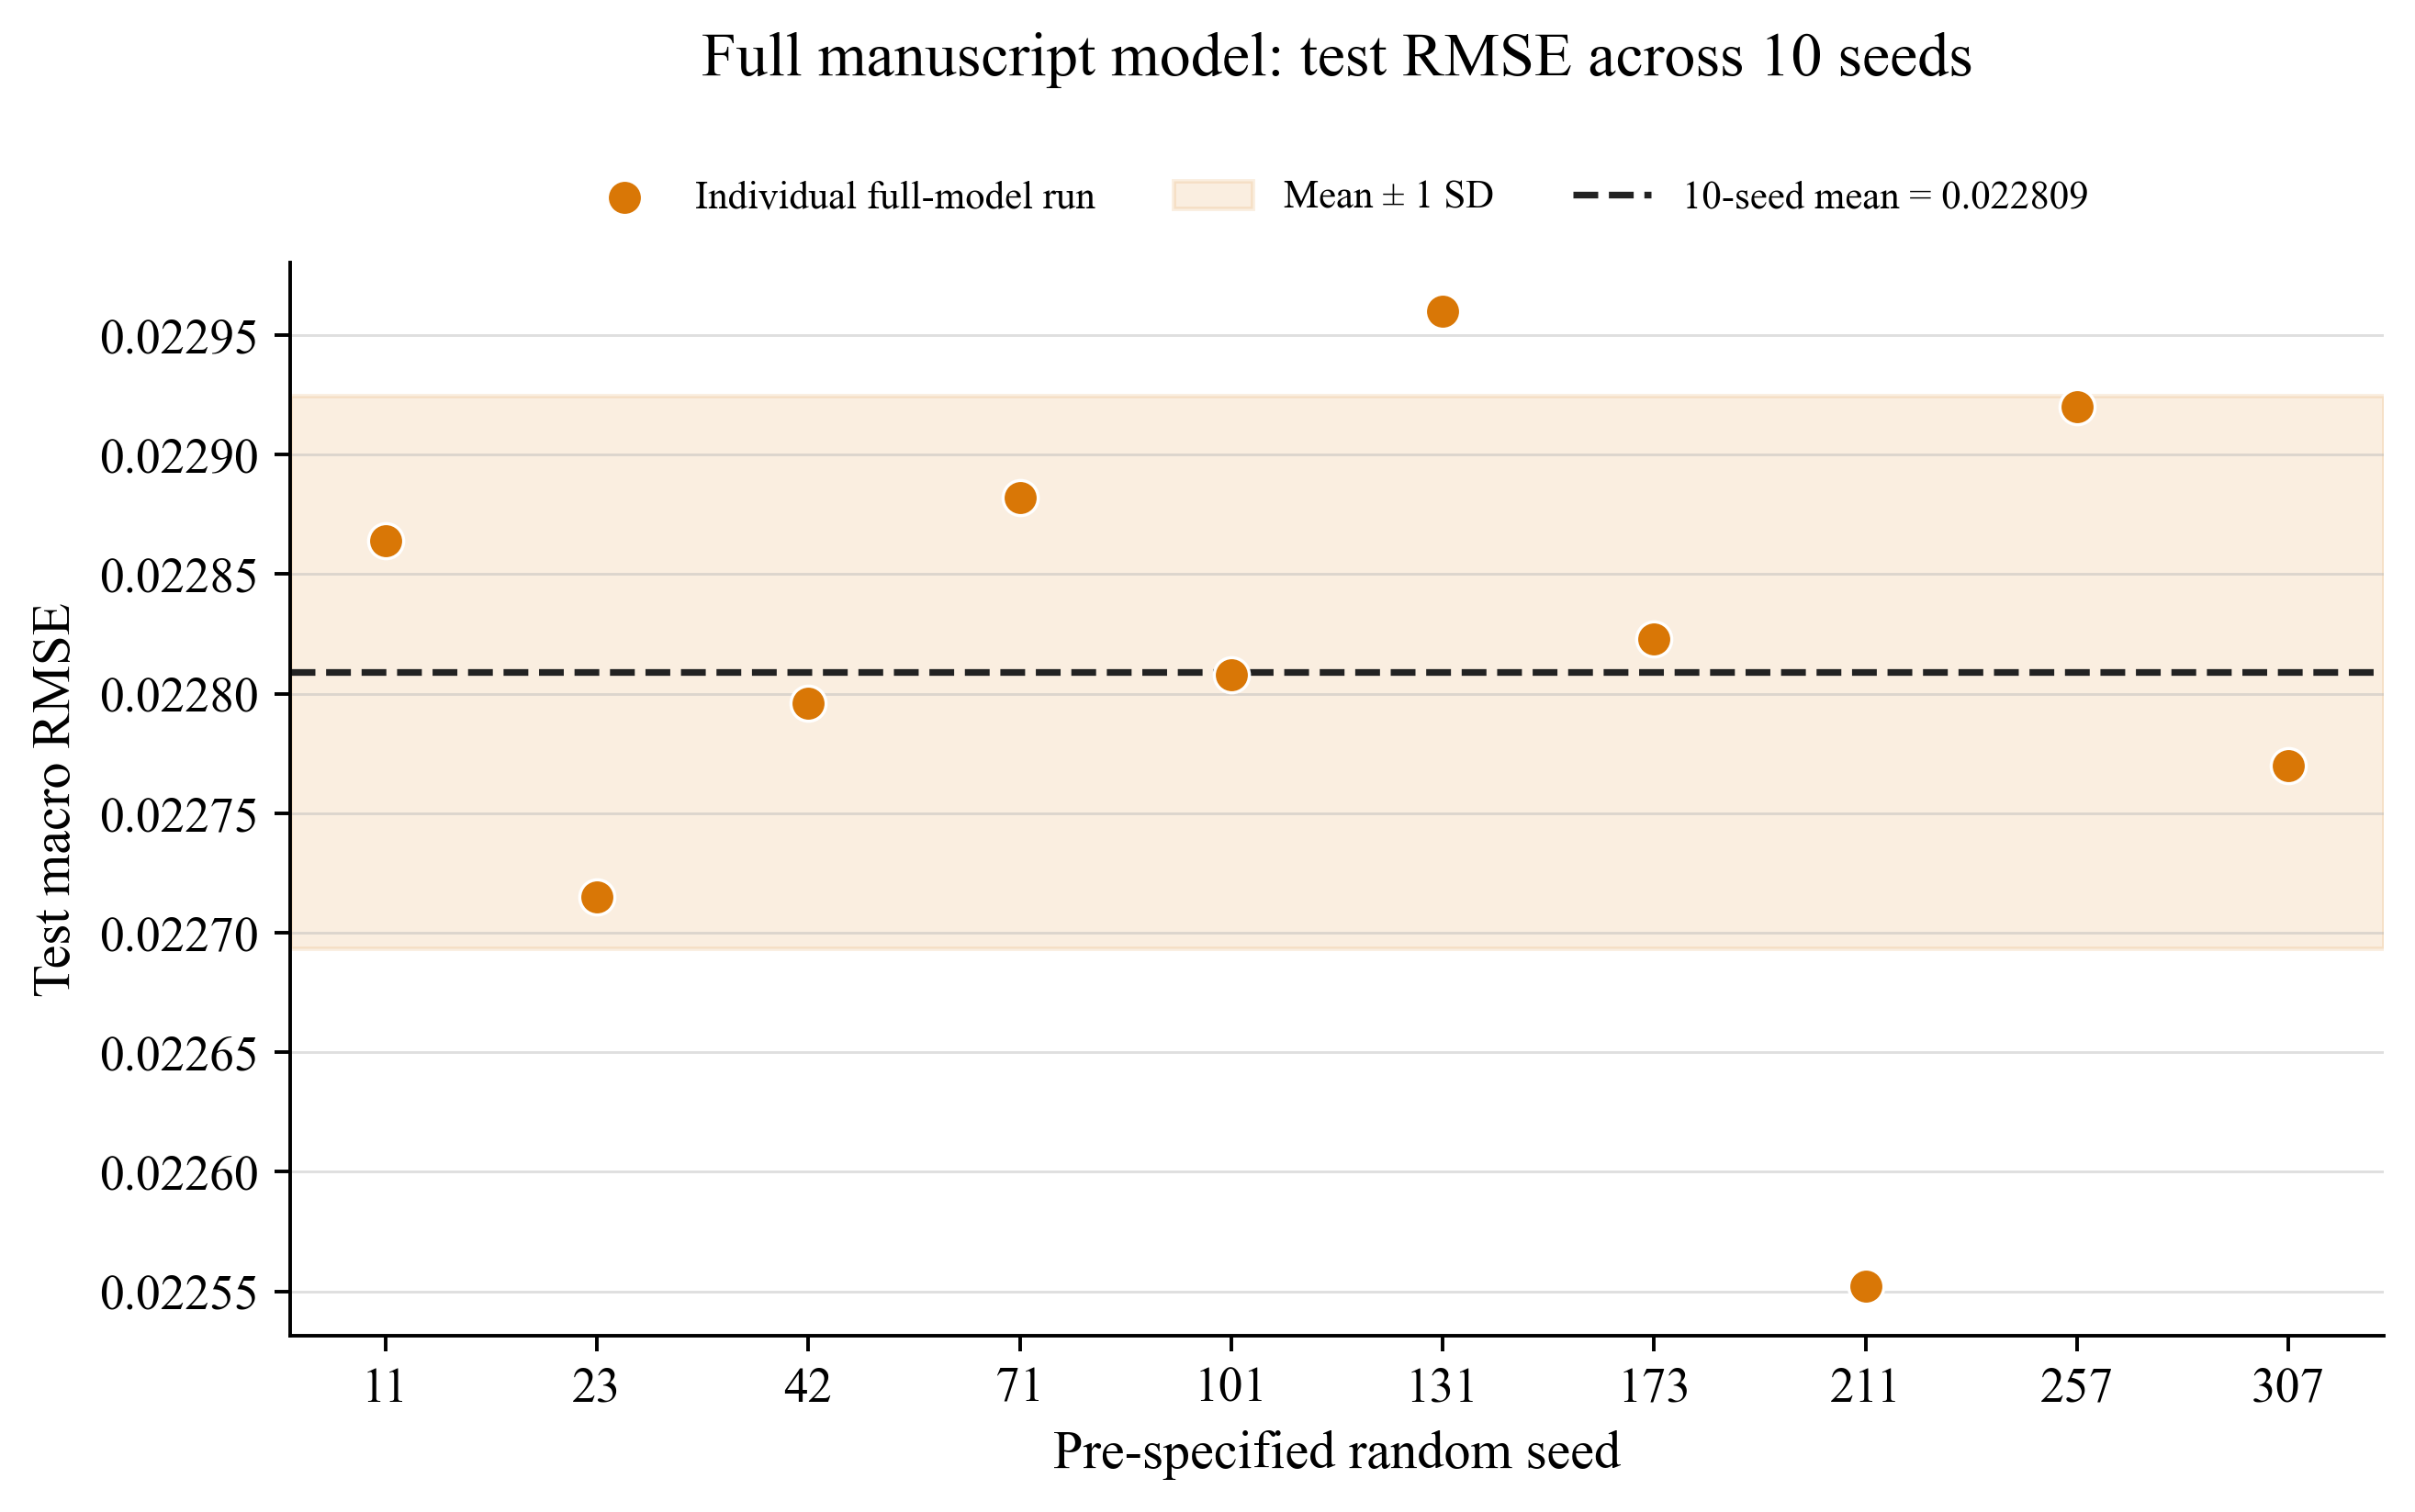

### Figure L2. Leave-one-scenario-out macro RMSE

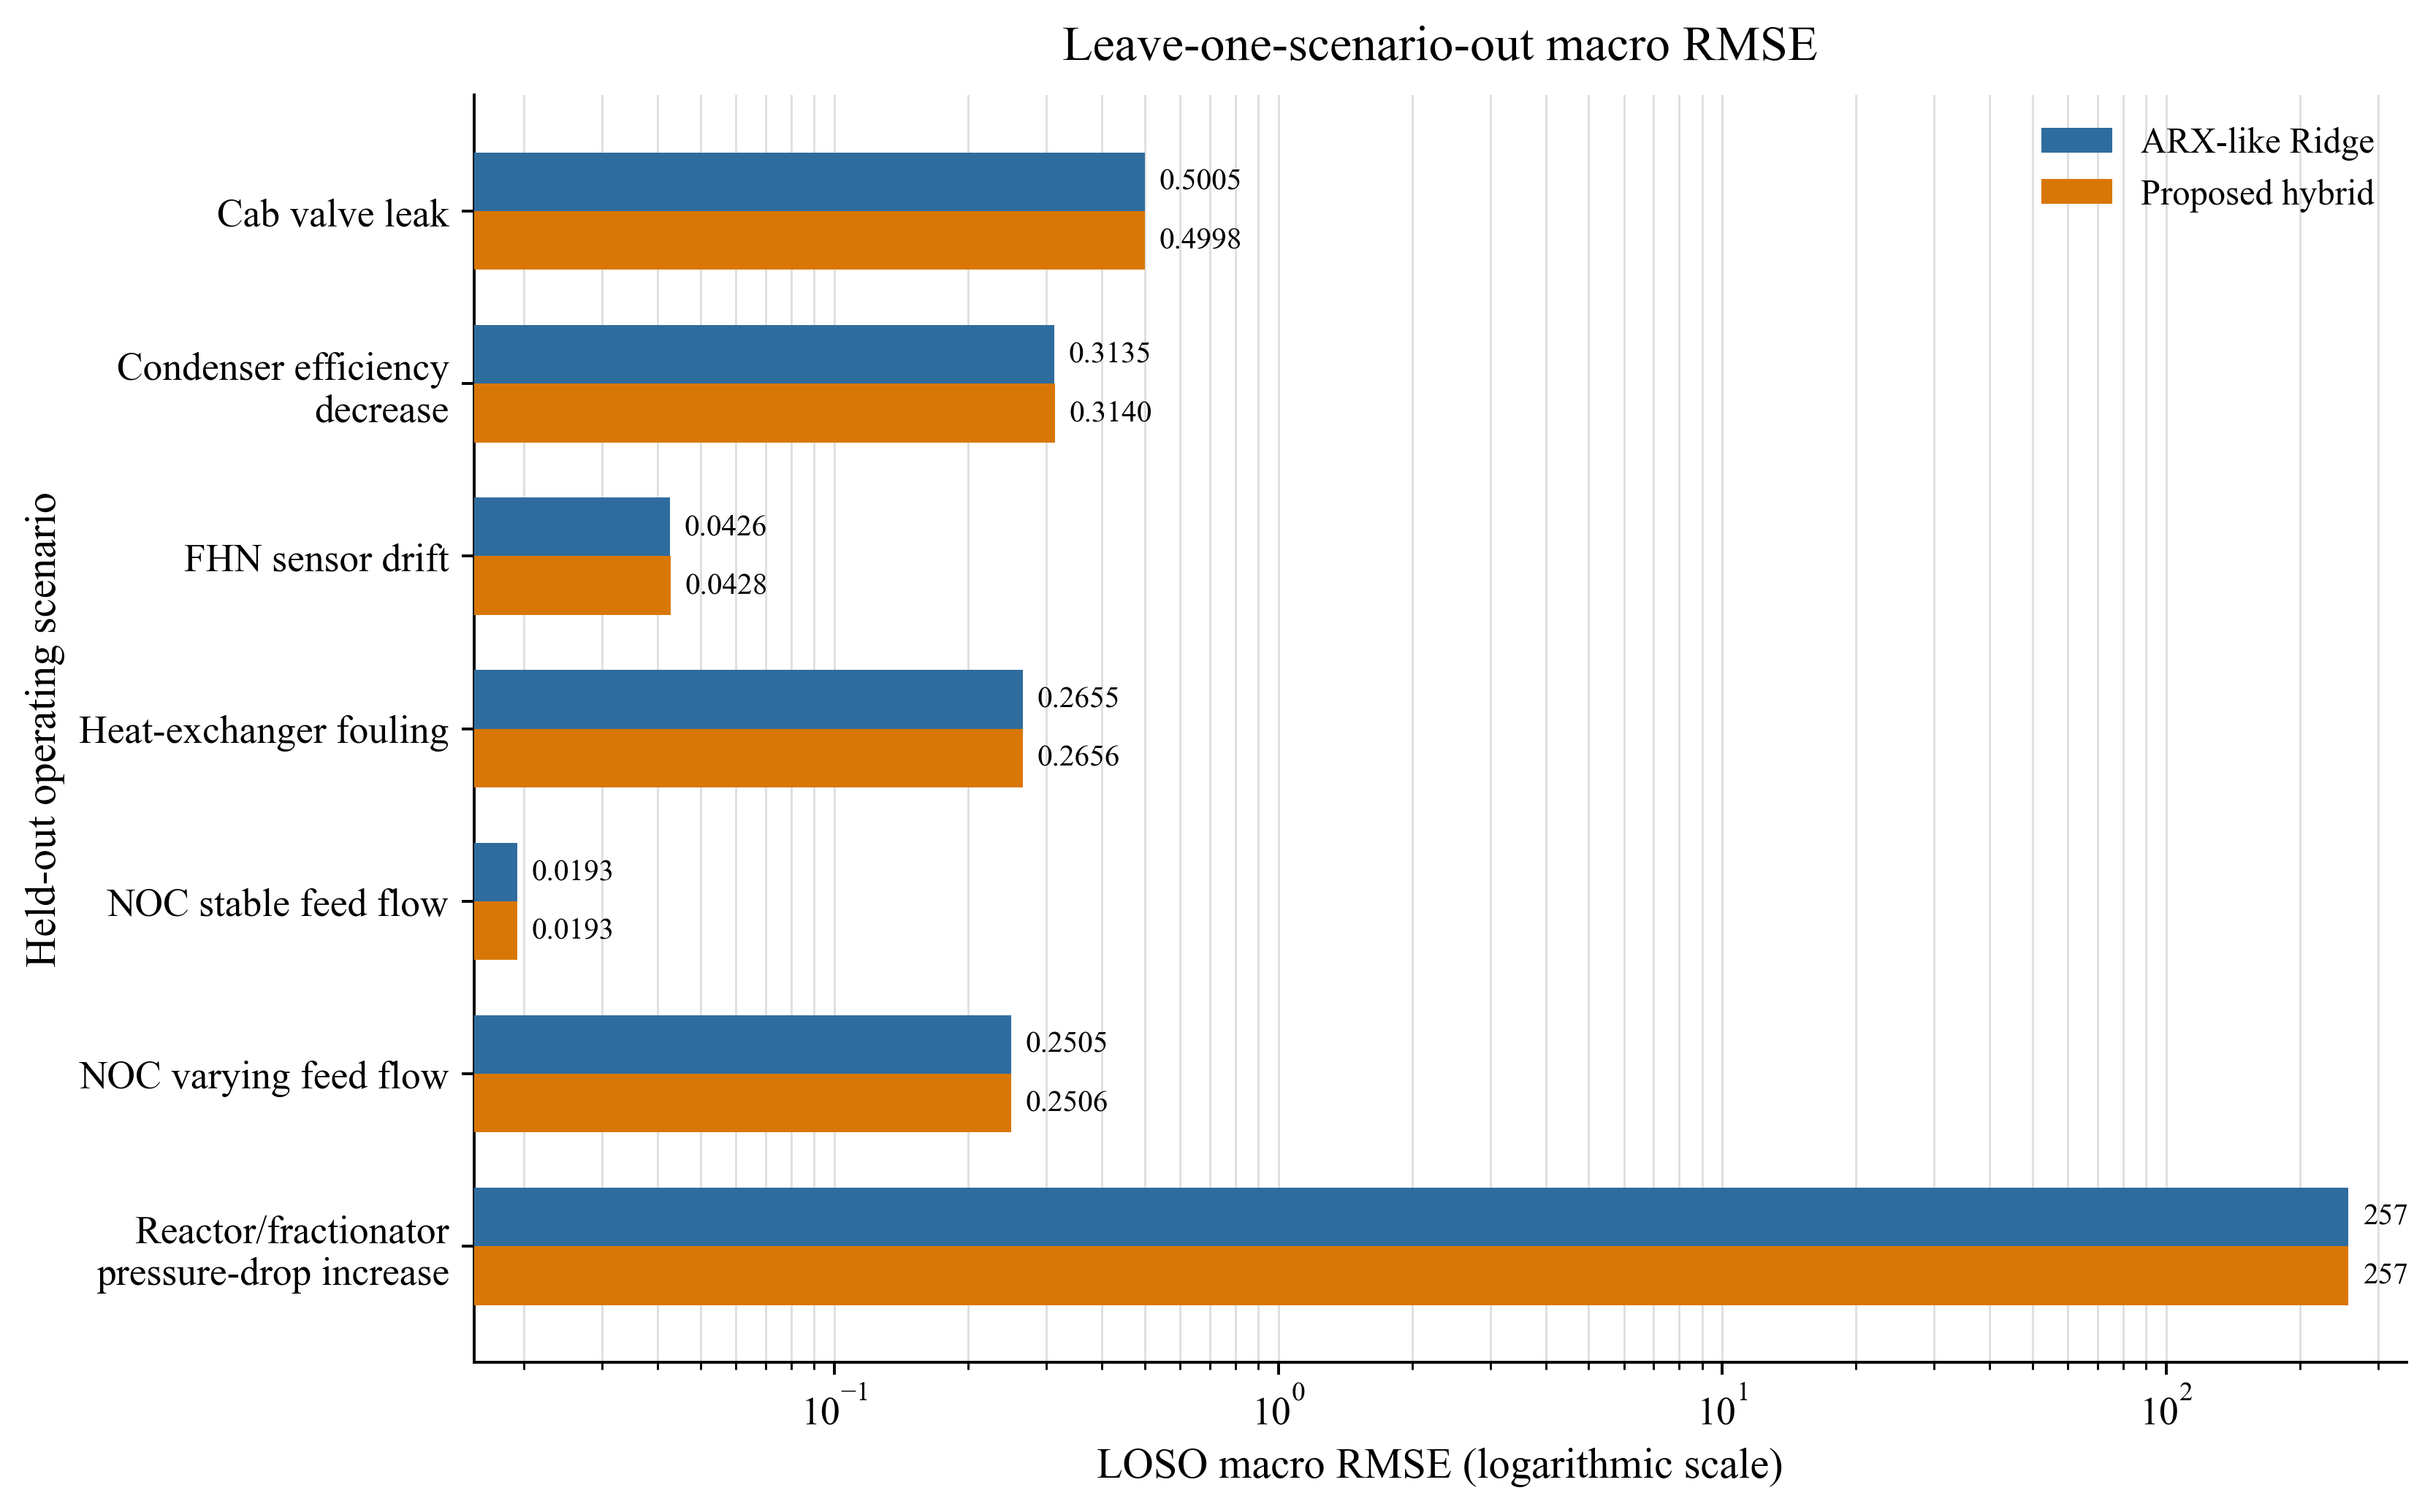

### Figure L3. Forecast-horizon sensitivity

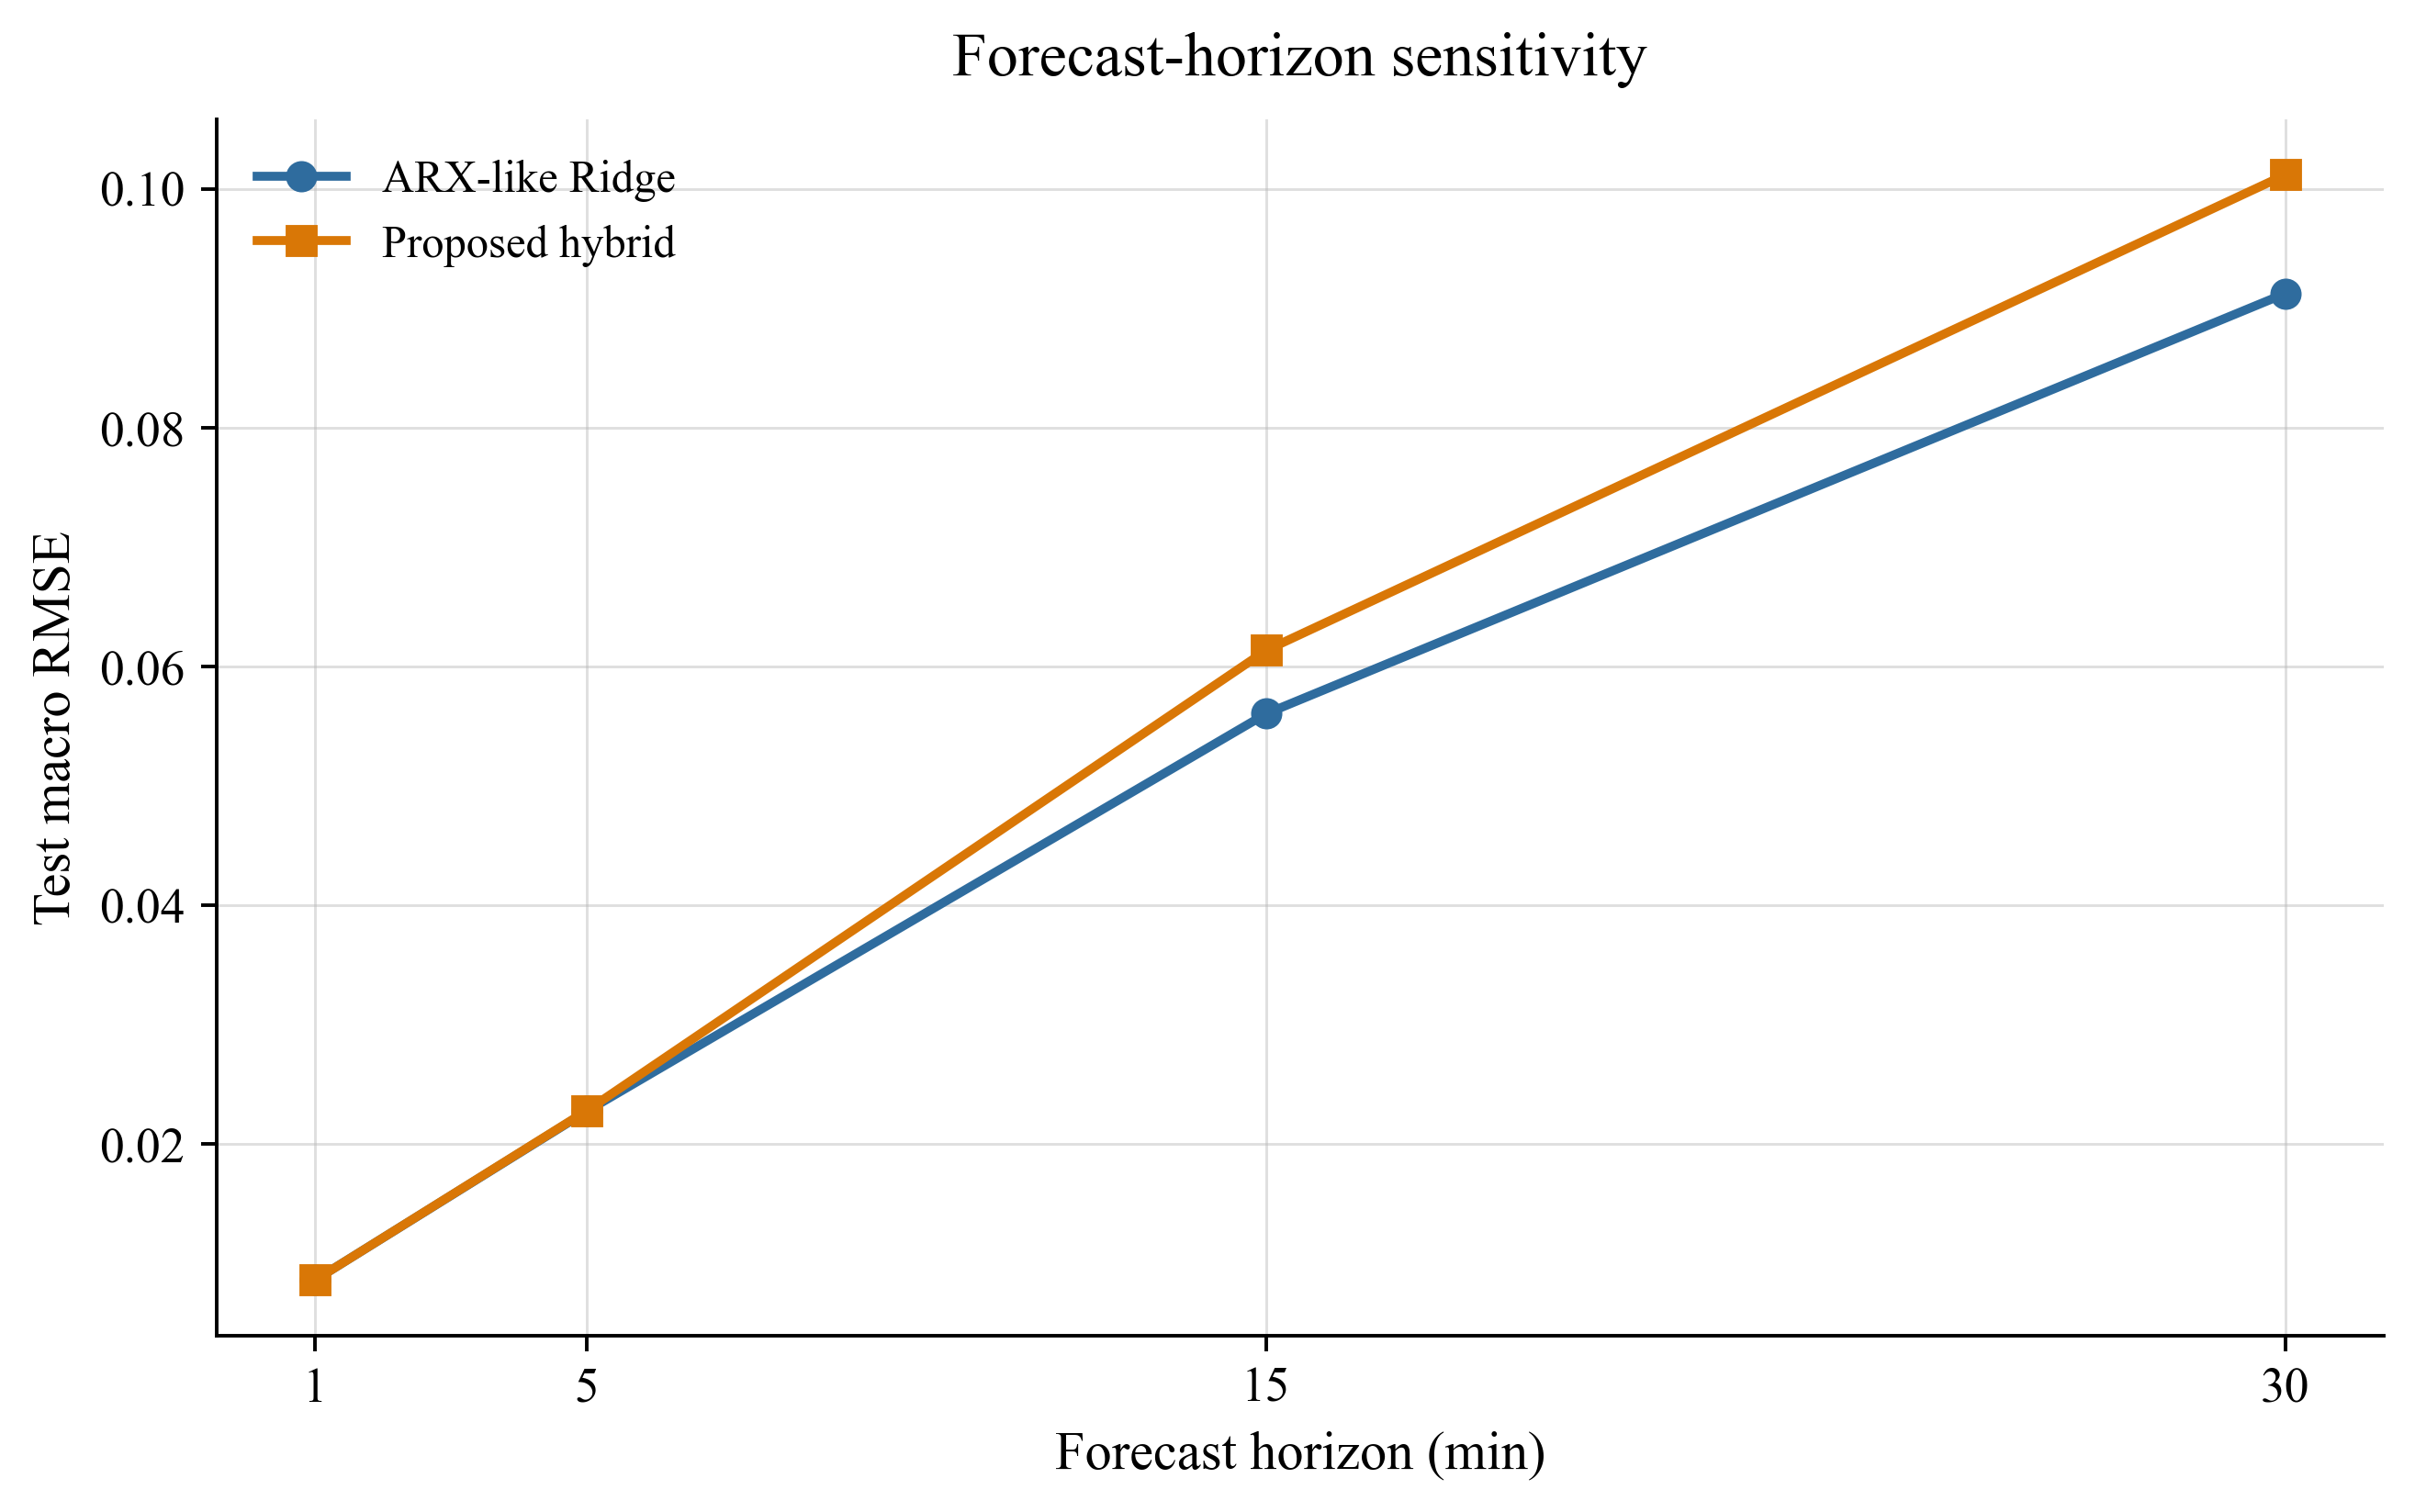

### Figure L4. Direct grouped Shapley importance averaged across target outputs

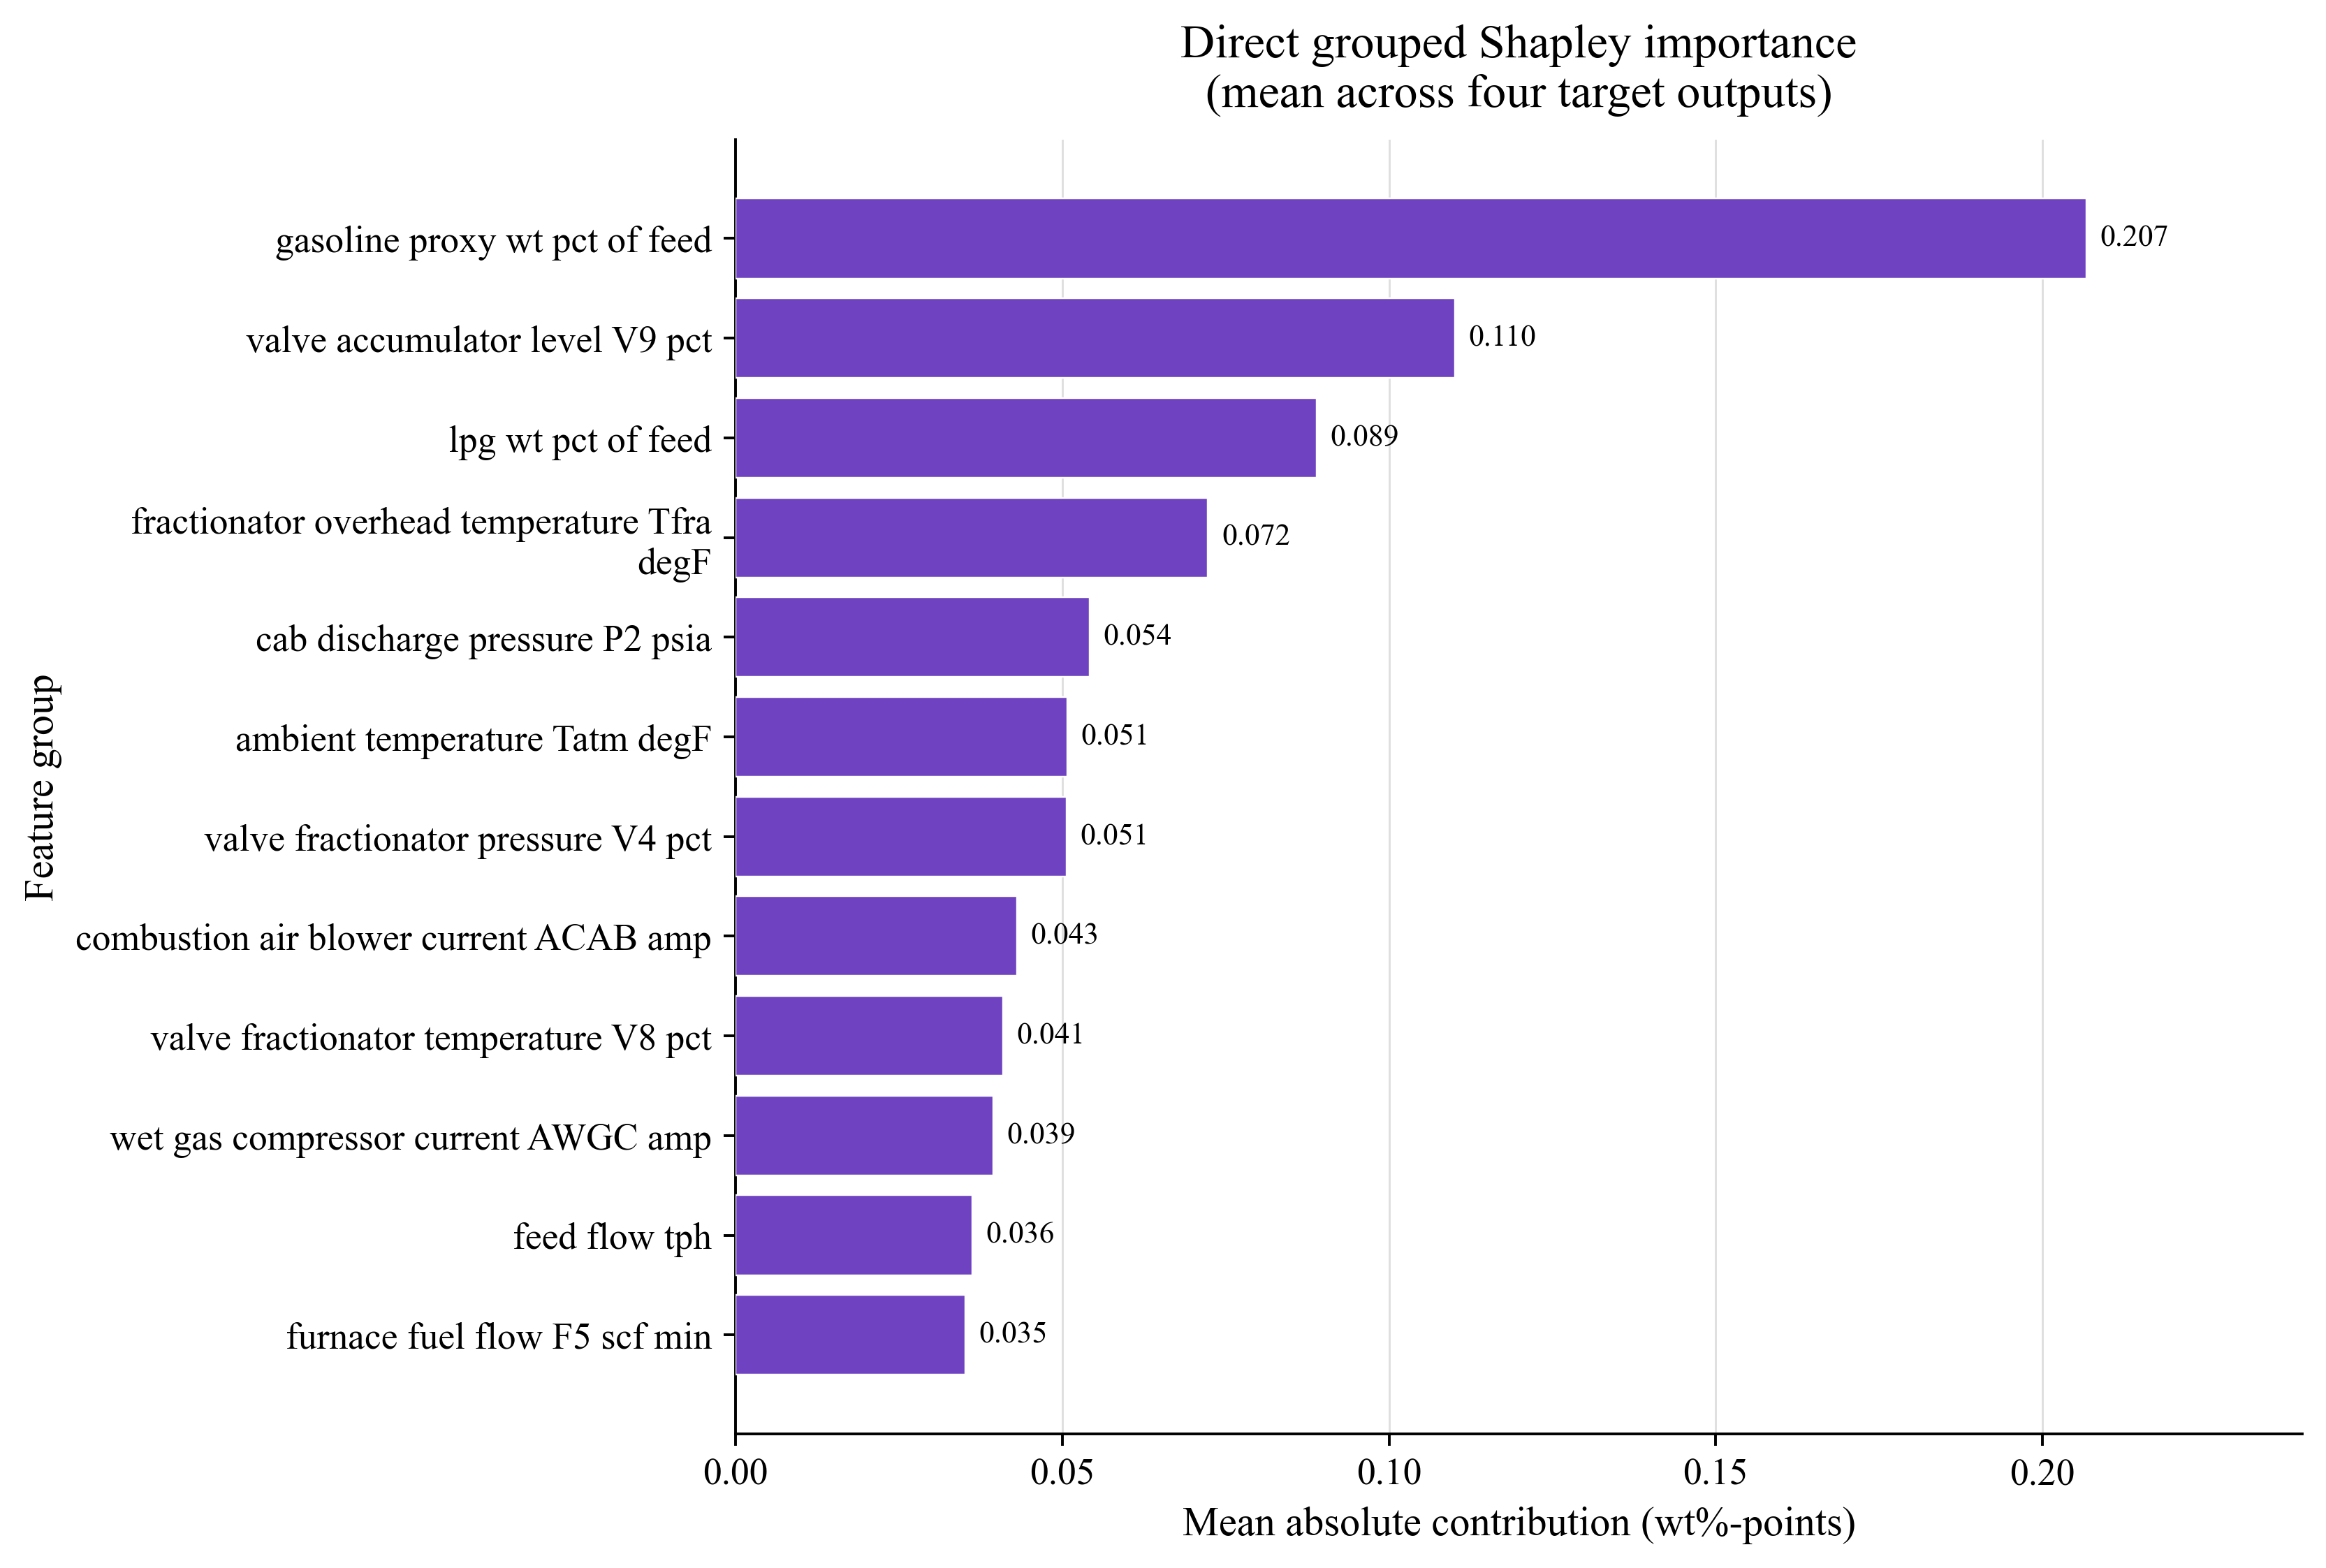

### Table L1. Executable reviewer-closure matrix

,reviewer_requirement,evidence,complete,status
0,Raw 47-column to analysis-ready 75-column provenance and target equations,Section A provenance/equation tables,True,COMPLETE
1,Algebraic-leakage and feature-wise forecast-time availability audit,Section A affine and 41-channel availability tables,True,COMPLETE
2,Exact manuscript proposed model retained,"Table B1; 178,332 trainable / 183,256 total / 4,924 frozen",True,COMPLETE
3,Numerically stable ARX solve with convergence guard,"Table B2; LSQR tol=1e-8; max_iter=10,000",True,COMPLETE
4,At least 10 independent full-model seeds,Tables C1-C4,True,COMPLETE
5,"Mean, SD, and confidence intervals",Table C2,True,COMPLETE
6,"Per-product, per-scenario, and equal normal/faulty errors",Tables C5-C8,True,COMPLETE
7,Learned residual coefficient alpha disclosed across seeds,Tables C4b-C4c,True,COMPLETE
8,DM-HAC and overlapping moving-block bootstrap,"Tables D1-D3; 7 ordered scenarios; 5,000 finite MBB draws; block length 35",True,COMPLETE
9,Multi-seed ablation,Tables E1-E3,True,COMPLETE


### Final technical evidence boundary

,model_identity,architecture_replaced,full_model_seed_runs,loso_folds,rolling_origins,forecast_horizons,sensitivity_runs,historical_test_status,remaining_confirmatory_requirement
0,Proposed Hybrid ARX–Residual Deep Sequence Model,False,10,7,3,4,7,post-selection/descriptive,new external or prospectively frozen trajectories


In [14]:
FIGURE_OUTPUT_DIR = Path('artifacts/fccu_04_journal_figures')
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DISPLAY_LABELS = {
    'ARX-like Ridge': 'ARX-like Ridge',
    PROPOSED_FINAL_MODEL: 'Proposed hybrid',
}
JOURNAL_BLUE, JOURNAL_ORANGE, JOURNAL_PURPLE = '#2F6C9E', '#D97706', '#6F42C1'

def save_and_show_journal_figure(fig, filename):
    fig.savefig(FIGURE_OUTPUT_DIR / filename, dpi=350, bbox_inches='tight', pad_inches=0.10, facecolor='white')
    plt.show()
    plt.close(fig)

display(Markdown('### Figure L1. Full manuscript model: test RMSE across 10 seeds'))
test_seed_plot = seed_results_df.query("split == 'test'").sort_values('seed').reset_index(drop=True)
seed_mean = float(test_seed_plot['rmse'].mean())
seed_sd = float(test_seed_plot['rmse'].std(ddof=1))
seed_x = np.arange(len(test_seed_plot))
fig_seed, ax_seed = plt.subplots(figsize=(8.2, 5.0), dpi=350, constrained_layout=True)
ax_seed.scatter(seed_x, test_seed_plot['rmse'], color=JOURNAL_ORANGE, edgecolor='white', linewidth=0.7, s=75, zorder=3, label='Individual full-model run')
ax_seed.axhspan(seed_mean - seed_sd, seed_mean + seed_sd, color=JOURNAL_ORANGE, alpha=0.12, zorder=1, label='Mean ± 1 SD')
ax_seed.axhline(seed_mean, color='#222222', linestyle='--', linewidth=1.5, zorder=2, label=f'10-seed mean = {seed_mean:.6f}')
ax_seed.set_xticks(seed_x, test_seed_plot['seed'].astype(int).astype(str))
ax_seed.set_xlabel('Pre-specified random seed')
ax_seed.set_ylabel('Test macro RMSE')
ax_seed.set_title('Full manuscript model: test RMSE across 10 seeds', pad=46)
ax_seed.grid(axis='y', color='#B8B8B8', linewidth=0.6, alpha=0.45)
ax_seed.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=3, fontsize=12)
save_and_show_journal_figure(fig_seed, 'figure_L1_full_model_seed_rmse.png')

display(Markdown('### Figure L2. Leave-one-scenario-out macro RMSE'))
loso_macro_plot = (loso_metrics_df.query("target == 'macro'")
                   .pivot(index='held_out_scenario', columns='model', values='rmse'))
scenario_labels = {
    'cab_valve_leak': 'Cab valve leak',
    'condenser_efficiency_decrease': 'Condenser efficiency decrease',
    'fhn_sensor_drift': 'FHN sensor drift',
    'heat_exchanger_fouling': 'Heat-exchanger fouling',
    'noc_stable_feed_flow': 'NOC stable feed flow',
    'noc_varying_feed_flow': 'NOC varying feed flow',
    'reactor_fractionator_pressure_drop_increase': 'Reactor/fractionator pressure-drop increase',
}
loso_y = np.arange(len(loso_macro_plot))
bar_height = 0.34
fig_loso, ax_loso = plt.subplots(figsize=(11.0, 6.8), dpi=350, constrained_layout=True)
for offset, model_name, color in [
    (-bar_height / 2, 'ARX-like Ridge', JOURNAL_BLUE),
    (bar_height / 2, PROPOSED_FINAL_MODEL, JOURNAL_ORANGE),
]:
    values = loso_macro_plot[model_name].to_numpy(float)
    bars = ax_loso.barh(loso_y + offset, values, height=bar_height, color=color, label=MODEL_DISPLAY_LABELS[model_name], zorder=3)
    for bar, value in zip(bars, values):
        value_label = f'{value:.3g}' if value >= 1 else f'{value:.4f}'
        ax_loso.annotate(value_label, (value, bar.get_y() + bar.get_height() / 2), xytext=(4, 0), textcoords='offset points', va='center', ha='left', fontsize=11)
ax_loso.set_yticks(loso_y, [fill(scenario_labels.get(name, name.replace('_', ' ')), 30) for name in loso_macro_plot.index])
ax_loso.invert_yaxis()
ax_loso.set_xscale('log')
ax_loso.set_xlabel('LOSO macro RMSE (logarithmic scale)')
ax_loso.set_ylabel('Held-out operating scenario')
ax_loso.set_title('Leave-one-scenario-out macro RMSE', pad=10)
ax_loso.xaxis.set_major_locator(mpl.ticker.LogLocator(base=10))
ax_loso.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax_loso.grid(axis='x', which='both', color='#B8B8B8', linewidth=0.6, alpha=0.45)
loso_values = loso_macro_plot.to_numpy(float)
ax_loso.set_xlim(float(loso_values.min()) * 0.80, float(loso_values.max()) * 1.35)
ax_loso.legend(frameon=False, loc='upper right', fontsize=13)
save_and_show_journal_figure(fig_loso, 'figure_L2_loso_macro_rmse.png')

display(Markdown('### Figure L3. Forecast-horizon sensitivity'))
horizon_plot = horizon_macro_df.query("split == 'test'")
fig_horizon, ax_horizon = plt.subplots(figsize=(8.2, 5.0), dpi=350, constrained_layout=True)
horizon_styles = {
    'ARX-like Ridge': {'color': JOURNAL_BLUE, 'marker': 'o'},
    PROPOSED_FINAL_MODEL: {'color': JOURNAL_ORANGE, 'marker': 's'},
}
for model_name in ['ARX-like Ridge', PROPOSED_FINAL_MODEL]:
    group = horizon_plot.query('model == @model_name').sort_values('horizon_min')
    ax_horizon.plot(group['horizon_min'], group['rmse'], linewidth=2.0, markersize=7, label=MODEL_DISPLAY_LABELS[model_name], **horizon_styles[model_name])
ax_horizon.set_xticks(sorted(horizon_plot['horizon_min'].unique()))
ax_horizon.set_xlabel('Forecast horizon (min)')
ax_horizon.set_ylabel('Test macro RMSE')
ax_horizon.set_title('Forecast-horizon sensitivity', pad=10)
ax_horizon.grid(color='#B8B8B8', linewidth=0.6, alpha=0.45)
ax_horizon.legend(frameon=False, loc='upper left', fontsize=13)
save_and_show_journal_figure(fig_horizon, 'figure_L3_forecast_horizon_sensitivity.png')

display(Markdown('### Figure L4. Direct grouped Shapley importance averaged across target outputs'))
importance_plot = (direct_shap_importance_df.groupby('feature_group', as_index=False)['mean_absolute_shapley_value']
                   .mean().nlargest(12, 'mean_absolute_shapley_value')
                   .sort_values('mean_absolute_shapley_value'))
importance_labels = [fill(name.replace('_', ' '), 40) for name in importance_plot['feature_group']]
fig_shap, ax_shap = plt.subplots(figsize=(11.0, 7.2), dpi=350, constrained_layout=True)
shap_bars = ax_shap.barh(importance_labels, importance_plot['mean_absolute_shapley_value'], color=JOURNAL_PURPLE, edgecolor='white', linewidth=0.5, zorder=3)
for bar, value in zip(shap_bars, importance_plot['mean_absolute_shapley_value']):
    ax_shap.annotate(f'{value:.3f}', (value, bar.get_y() + bar.get_height() / 2), xytext=(4, 0), textcoords='offset points', va='center', ha='left', fontsize=11)
ax_shap.set_xlabel('Mean absolute contribution (wt%-points)')
ax_shap.set_ylabel('Feature group')
ax_shap.set_title('Direct grouped Shapley importance\n(mean across four target outputs)', pad=10)
ax_shap.grid(axis='x', color='#B8B8B8', linewidth=0.6, alpha=0.45)
ax_shap.set_xlim(0, float(importance_plot['mean_absolute_shapley_value'].max()) * 1.16)
save_and_show_journal_figure(fig_shap, 'figure_L4_direct_grouped_shapley_importance.png')

closure_rows = [
    {'reviewer_requirement': 'Raw 47-column to analysis-ready 75-column provenance and target equations', 'evidence': 'Section A provenance/equation tables', 'complete': len(source_dictionary_df) == 47 and len(final_dictionary_df) == 75 and target_equation_df['maximum_absolute_reconstruction_error'].max() < 1e-9},
    {'reviewer_requirement': 'Algebraic-leakage and feature-wise forecast-time availability audit', 'evidence': 'Section A affine and 41-channel availability tables', 'complete': not affine_leakage_screen_df['exact_affine_duplicate_detected'].any() and forecast_availability_df['causal_and_available'].all() and len(feature_availability_df) == 41 and feature_availability_df['available_at_inference'].all() and not feature_availability_df['future_value_used'].any() and len(feature_cols) == 37},
    {'reviewer_requirement': 'Exact manuscript proposed model retained', 'evidence': 'Table B1; 178,332 trainable / 183,256 total / 4,924 frozen', 'complete': count_parameters(primary_seed_model, trainable_only=True) == 178332 and count_parameters(primary_seed_model) == 183256 and count_parameters(primary_seed_model) - count_parameters(primary_seed_model, trainable_only=True) == 4924},
    {'reviewer_requirement': 'Numerically stable ARX solve with convergence guard', 'evidence': 'Table B2; LSQR tol=1e-8; max_iter=10,000', 'complete': (base_arx['selection']['solver'] == 'lsqr').all() and base_arx['selection']['converged_before_max_iter'].all() and (base_arx['selection']['solver_iterations'] < ARX_SOLVER_MAX_ITERATIONS).all()},
    {'reviewer_requirement': 'At least 10 independent full-model seeds', 'evidence': 'Tables C1-C4', 'complete': seed_results_df['seed'].nunique() == 10 and len(seed_constraint_df) == 10},
    {'reviewer_requirement': 'Mean, SD, and confidence intervals', 'evidence': 'Table C2', 'complete': len(seed_summary_df) == 2 * 5 * 4 and seed_summary_df[['mean', 'std', 'ci95_lower', 'ci95_upper']].notna().all().all()},
    {'reviewer_requirement': 'Per-product, per-scenario, and equal normal/faulty errors', 'evidence': 'Tables C5-C8', 'complete': len(scenario_target_metrics_df) == 7 * 5 and len(condition_stratified_test_df) == 2 * 5 and len(condition_balanced_test_df) == 5 and np.allclose(condition_balanced_test_df[['normal_weight', 'faulty_weight']], 0.5)},
    {'reviewer_requirement': 'Learned residual coefficient alpha disclosed across seeds', 'evidence': 'Tables C4b-C4c', 'complete': len(residual_coefficient_df) == 10 * 4 and residual_coefficient_df['seed'].nunique() == 10 and np.isfinite(residual_coefficient_df['learned_residual_coefficient_alpha']).all()},
    {'reviewer_requirement': 'DM-HAC and overlapping moving-block bootstrap', 'evidence': 'Tables D1-D3; 7 ordered scenarios; 5,000 finite MBB draws; block length 35', 'complete': len(dm_hac_df) == 10 and (dm_hac_df['hac_lag'] == DEPENDENCE_LAG).all() and len(loss_difference_by_scenario) == 7 and len(mbb_distribution) == MBB_REPETITIONS == 5000 and np.isfinite(mbb_distribution).all() and len(moving_block_bootstrap_df) == 1 and int(moving_block_bootstrap_df['overlapping_block_length'].iloc[0]) == DEPENDENCE_LAG + 1 and float(moving_block_bootstrap_df['ci95_lower'].iloc[0]) <= float(moving_block_bootstrap_df['ci95_upper'].iloc[0])},
    {'reviewer_requirement': 'Multi-seed ablation', 'evidence': 'Tables E1-E3', 'complete': ablation_runs_df['seed'].nunique() == len(ABLATION_SEEDS) and ablation_runs_df['ablation'].nunique() == len(ABLATION_SPECS)},
    {'reviewer_requirement': 'Leave-one-scenario-out evaluation', 'evidence': 'Tables F1-F4', 'complete': len(loso_protocol_df) == 7 and not loso_protocol_df['held_out_seen_in_development'].any()},
    {'reviewer_requirement': 'Multiple forecasting horizons', 'evidence': 'Tables G1-G2', 'complete': set(horizon_protocol_df['horizon_min']) == set(REVIEWER_HORIZONS)},
    {'reviewer_requirement': 'Development-only rolling-origin evaluation', 'evidence': 'Tables G3-G4', 'complete': len(rolling_protocol_df) == 3 and (rolling_protocol_df['historical_test_rows_used'] == 0).all()},
    {'reviewer_requirement': 'ARX+MLP/GRU/TCN residual comparators', 'evidence': 'Tables H1-H3', 'complete': residual_runs_df['model'].nunique() == 3 and residual_runs_df['seed'].nunique() == len(COMPARATOR_SEEDS)},
    {'reviewer_requirement': 'Direct explanation of final model', 'evidence': 'Tables I1-I2; 32 antithetic pairs / 64 direct permutations with MC SE', 'complete': bool(direct_shap_audit_df['direct_model_calls'].iloc[0]) and direct_shap_audit_df['max_abs_local_accuracy_error'].iloc[0] < 1e-3 and int(direct_shap_audit_df['antithetic_pairs'].iloc[0]) == 32 and np.isfinite(grouped_shap_mc_se).all()},
    {'reviewer_requirement': 'Surrogate fidelity measured separately', 'evidence': 'Table I3', 'complete': len(surrogate_fidelity_df) == 4 and surrogate_fidelity_df[['fidelity_rmse', 'fidelity_r2']].notna().all().all()},
    {'reviewer_requirement': 'Symmetric proposed-versus-ARX deployment cost', 'evidence': 'Table I4; matched latency repeats; end-to-end hybrid includes ARX initialization', 'complete': set(deployment_cost_df['model']) == {PROPOSED_FINAL_MODEL, 'ARX-like Ridge'} and len(deployment_cost_df) == 14 and deployment_cost_df[['value', 'backend', 'repetitions_or_aggregation', 'timing_boundary']].notna().all().all() and np.isclose(float(deployment_cost_df.query("model == @PROPOSED_FINAL_MODEL and measure == 'end-to-end training time'")['value'].iloc[0]), base_arx_training_time_sec + NEURAL_TRAINING_TIME_MEDIAN_SEC) and np.isclose(float(deployment_cost_df.query("model == 'ARX-like Ridge' and measure == 'end-to-end training time'")['value'].iloc[0]), base_arx_training_time_sec) and (deployment_cost_df[deployment_cost_df['measure'].str.contains('latency')]['repetitions_or_aggregation'] == '50 timed passes after 1 warm-up').all()},
    {'reviewer_requirement': 'Nonempty lookback, horizon, and seed sensitivity', 'evidence': 'Tables J1-J2', 'complete': len(sensitivity_df) == len(SENSITIVITY_CONFIGURATIONS) and sensitivity_df[['rmse', 'mae', 'r2', 'smape']].notna().all().all()},
    {'reviewer_requirement': 'Factual unified executed configurations and budgets', 'evidence': 'Section K; documents the FCCU_03 Optuna search and frozen FCCU_04 evaluation', 'complete': len(hyperparameter_registry_df) == 20 and hyperparameter_registry_df['model'].nunique() == len(hyperparameter_registry_df) and hyperparameter_registry_df[['executed_configuration_or_space', 'actual_tuning_budget', 'execution_evidence']].notna().all().all()},
]
reviewer_closure_df = pd.DataFrame(closure_rows)
reviewer_closure_df['status'] = np.where(reviewer_closure_df['complete'], 'COMPLETE', 'INCOMPLETE')
display(Markdown('### Table L1. Executable reviewer-closure matrix'))
display(reviewer_closure_df)
assert reviewer_closure_df['complete'].all(), reviewer_closure_df.loc[~reviewer_closure_df['complete']]

final_evidence_df = pd.DataFrame([{
    'model_identity': PROPOSED_FINAL_MODEL,
    'architecture_replaced': False,
    'full_model_seed_runs': seed_results_df['seed'].nunique(),
    'loso_folds': len(loso_protocol_df),
    'rolling_origins': len(rolling_protocol_df),
    'forecast_horizons': horizon_protocol_df['horizon_min'].nunique(),
    'sensitivity_runs': len(sensitivity_df),
    'historical_test_status': 'post-selection/descriptive',
    'remaining_confirmatory_requirement': 'new external or prospectively frozen trajectories',
}])
display(Markdown('### Final technical evidence boundary'))
display(final_evidence_df)
